# Comprensión y EDA - Riesgo Crediticio

**Autor:** Juan Martín Rossi
**Fecha:** 2026-08-26

**Objetivo de este notebook:** explorar en profundidad el dataset de créditos otorgados (`Base_de_datos.csv`, generado por `cargar_datos.ipynb`) para entender su estructura, calidad y contenido antes de modelar. Esta primera parte cubre **exploración inicial y saneamiento de tipos**: caracterización de variables, unificación de nulos, casteo a los tipos correctos, identificación de columnas candidatas a eliminar (sin borrarlas todavía) y documentación de anomalías. El análisis univariable, bivariable y multivariable, y las conclusiones accionables, van en secciones posteriores de este mismo notebook.

## Diccionario de datos

23 columnas, una fila por crédito otorgado. Montos en pesos colombianos (COP). `puntaje_datacredito` es el score del buró de crédito colombiano DataCrédito.

| Columna | Significado de negocio | Tipo esperado |
|---|---|---|
| `tipo_credito` | Código del tipo/producto de crédito otorgado | Categórica nominal |
| `fecha_prestamo` | Fecha y hora en que se otorgó el crédito | Fecha |
| `capital_prestado` | Monto de capital otorgado (COP) | Numérica continua |
| `plazo_meses` | Plazo pactado del crédito, en meses | Numérica discreta |
| `edad_cliente` | Edad del cliente en años | Numérica discreta |
| `tipo_laboral` | Situación laboral del cliente (Empleado / Independiente) | Dicotómica |
| `salario_cliente` | Ingreso mensual declarado del cliente (COP) | Numérica continua |
| `total_otros_prestamos` | Saldo de otras deudas del cliente al momento de la solicitud (COP) | Numérica continua |
| `cuota_pactada` | Valor de la cuota mensual pactada (COP) | Numérica continua |
| `puntaje` | Score interno de originación de la entidad | Numérica continua |
| `puntaje_datacredito` | Score del buró DataCrédito | Numérica discreta |
| `cant_creditosvigentes` | Cantidad de créditos vigentes del cliente en el sistema financiero | Numérica discreta |
| `huella_consulta` | Cantidad de consultas de crédito recientes sobre el cliente | Numérica discreta |
| `saldo_mora` | Saldo en mora del cliente en otros créditos (COP) | Numérica continua |
| `saldo_total` | Saldo total de deuda del cliente en el sistema (COP) | Numérica continua |
| `saldo_principal` | Saldo de capital de la deuda del cliente, sin mora (COP) | Numérica continua |
| `saldo_mora_codeudor` | Saldo en mora del codeudor del crédito (COP) | Numérica continua |
| `creditos_sectorFinanciero` | Cantidad de créditos vigentes en el sector financiero (bancos) | Numérica discreta |
| `creditos_sectorCooperativo` | Cantidad de créditos vigentes en el sector cooperativo | Numérica discreta |
| `creditos_sectorReal` | Cantidad de créditos vigentes en el sector real (comercio/retail) | Numérica discreta |
| `promedio_ingresos_datacredito` | Promedio de ingresos del cliente reportado por DataCrédito (COP) | Numérica continua |
| `tendencia_ingresos` | Tendencia de los ingresos del cliente según DataCrédito | Categórica ordinal |
| **`Pago_atiempo`** | **Variable objetivo: 1 = pagó a tiempo, 0 = no pagó a tiempo** | **Dicotómica (target)** |


## Carga del dataset

Se carga el `.csv` materializado por `cargar_datos.ipynb`, otra vez con `dtype=str`: el saneamiento de tipos es justamente el trabajo de este notebook, así que no tiene sentido dejar que `pandas` infiera tipos por su cuenta antes de decidir nosotros cómo castear cada columna.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_CSV = RAIZ / "data" / "raw" / "Base_de_datos.csv"

df = pd.read_csv(RUTA_CSV, dtype=str, encoding="utf-8")
df.shape

(10763, 23)

## Descripción general

Antes de mirar columna por columna, un pantallazo del dataset completo: forma, tipos que trae desde el CSV (todos `object`, esperado), memoria que ocupa en memoria (no en disco), cuántas filas son duplicados exactos (indicaría créditos cargados dos veces) y cuántos valores distintos tiene cada columna (una primera pista de cardinalidad).

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (10763, 23)
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   tipo_credito                   10763 non-null  str  
 1   fecha_prestamo                 10763 non-null  str  
 2   capital_prestado               10763 non-null  str  
 3   plazo_meses                    10763 non-null  str  
 4   edad_cliente                   10763 non-null  str  
 5   tipo_laboral                   10763 non-null  str  
 6   salario_cliente                10763 non-null  str  
 7   total_otros_prestamos          10763 non-null  str  
 8   cuota_pactada                  10763 non-null  str  
 9   puntaje                        10763 non-null  str  
 10  puntaje_datacredito            10757 non-null  str  
 11  cant_creditosvigentes          10763 non-null  str  
 12  huella_consulta                10763 non-null  str  
 13  saldo_mo

In [3]:
memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memoria usada: {memoria_mb:.2f} MB")

filas_duplicadas = df.duplicated().sum()
print(f"Filas duplicadas exactas: {filas_duplicadas}")

Memoria usada: 3.03 MB
Filas duplicadas exactas: 0


In [4]:
valores_unicos = df.nunique(dropna=True).sort_values(ascending=False)
valores_unicos

fecha_prestamo                   10758
cuota_pactada                     9836
saldo_total                       8892
saldo_principal                   8692
capital_prestado                  7306
promedio_ingresos_datacredito     5309
total_otros_prestamos             1538
salario_cliente                   1385
puntaje_datacredito                472
puntaje                            248
saldo_mora                          57
edad_cliente                        54
tendencia_ingresos                  46
cant_creditosvigentes               39
creditos_sectorFinanciero           33
huella_consulta                     28
creditos_sectorReal                 24
plazo_meses                         18
creditos_sectorCooperativo          11
tipo_credito                         6
saldo_mora_codeudor                  5
tipo_laboral                         2
Pago_atiempo                         2
dtype: int64

## Caracterización de variables

Se arma una tabla resumen con `pandas` (cardinalidad, `% de nulos` y ejemplos calculados, no tipeados a mano) y se le suma el **tipo semántico**, que es la única columna que requiere criterio de negocio y no se puede inferir automáticamente del dtype. Dos casos a tener en cuenta explícitamente: `tipo_credito` trae códigos numéricos pero es **categórica nominal** (el número es una etiqueta, no una cantidad — sumar o promediar códigos de tipo de crédito no tiene sentido), y `tendencia_ingresos` es **categórica ordinal** (`Decreciente` < `Estable` < `Creciente` tiene un orden natural).

In [5]:
TIPO_SEMANTICO = {
    "tipo_credito": "categórica nominal",
    "fecha_prestamo": "fecha",
    "capital_prestado": "numérica continua",
    "plazo_meses": "numérica discreta",
    "edad_cliente": "numérica discreta",
    "tipo_laboral": "dicotómica",
    "salario_cliente": "numérica continua",
    "total_otros_prestamos": "numérica continua",
    "cuota_pactada": "numérica continua",
    "puntaje": "numérica continua",
    "puntaje_datacredito": "numérica discreta",
    "cant_creditosvigentes": "numérica discreta",
    "huella_consulta": "numérica discreta",
    "saldo_mora": "numérica continua",
    "saldo_total": "numérica continua",
    "saldo_principal": "numérica continua",
    "saldo_mora_codeudor": "numérica continua",
    "creditos_sectorFinanciero": "numérica discreta",
    "creditos_sectorCooperativo": "numérica discreta",
    "creditos_sectorReal": "numérica discreta",
    "promedio_ingresos_datacredito": "numérica continua",
    "tendencia_ingresos": "categórica ordinal",
    "Pago_atiempo": "dicotómica (variable objetivo)",
}

caracterizacion = pd.DataFrame({
    "columna": df.columns,
    "tipo_detectado": [str(df[c].dtype) for c in df.columns],
    "tipo_semantico": [TIPO_SEMANTICO[c] for c in df.columns],
    "cardinalidad": [df[c].nunique(dropna=True) for c in df.columns],
    "pct_nulos": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "ejemplos": [list(df[c].dropna().unique()[:3]) for c in df.columns],
})
caracterizacion

,columna,tipo_detectado,tipo_semantico,cardinalidad,pct_nulos,ejemplos
0,tipo_credito,str,categórica nominal,6,0.00,"[7, 4, 9]"
1,fecha_prestamo,str,fecha,10758,0.00,"[2024-12-21 11:31:35, 2025-04-22 09:47:35, 202..."
2,capital_prestado,str,numérica continua,7306,0.00,"[3692160, 840000, 5974028.399999999]"
3,plazo_meses,str,numérica discreta,18,0.00,"[10, 6, 11]"
4,edad_cliente,str,numérica discreta,54,0.00,"[42, 60, 36]"
5,tipo_laboral,str,dicotómica,2,0.00,"[Independiente, Empleado]"
6,salario_cliente,str,numérica continua,1385,0.00,"[8000000, 3000000, 4036000]"
7,total_otros_prestamos,str,numérica continua,1538,0.00,"[2500000, 2000000, 829000]"
8,cuota_pactada,str,numérica continua,9836,0.00,"[341296, 124876, 529554]"
9,puntaje,str,numérica continua,248,0.00,"[88.768094, 95.227787, 47.613894]"


## Unificación de nulos

Pandas ya interpreta como `NaN` algunas formas comunes de faltante al leer el CSV (celda vacía, `NA`, `N/A`, `null`, `None`, entre otras de su lista por defecto). Pero eso no cubre todo: hay que buscar explícitamente espacios en blanco, guiones, signos de pregunta, y **ceros que en realidad significan "sin dato"** — este último caso no se puede aplicar a ciegas a todas las columnas (un `0` en `creditos_sectorReal` es un dato real: "no tiene créditos en ese sector"), así que se justifica columna por columna.

Se registra el conteo de nulos **antes** de tocar nada, para poder comparar contra el de después.

In [6]:
nulos_antes = df.isna().sum()
nulos_antes.sort_values(ascending=False)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_total                       156
saldo_mora                        156
puntaje_datacredito                 6
tipo_credito                        0
huella_consulta                     0
creditos_sectorReal                 0
creditos_sectorCooperativo          0
creditos_sectorFinanciero           0
cant_creditosvigentes               0
fecha_prestamo                      0
puntaje                             0
cuota_pactada                       0
total_otros_prestamos               0
salario_cliente                     0
tipo_laboral                        0
edad_cliente                        0
plazo_meses                         0
capital_prestado                    0
Pago_atiempo                        0
dtype: int64

Formas de faltante a unificar a `np.nan`, además de lo que pandas ya detectó: celda vacía, string vacío, solo espacios, `"NA"`, `"N/A"`, `"null"`, `"None"`, `"-"`, `"?"`.

In [7]:
SENTINELS_TEXTO = {"", "NA", "N/A", "null", "None", "-", "?"}


def es_sentinel(valor):
    if pd.isna(valor):
        return True
    return str(valor).strip() in SENTINELS_TEXTO


sentinels_encontrados = 0
for columna in df.columns:
    mascara = df[columna].apply(es_sentinel) & df[columna].notna()
    if mascara.any():
        print(f"{columna}: {mascara.sum()} sentinels de texto encontrados")
        sentinels_encontrados += mascara.sum()
    df.loc[df[columna].apply(es_sentinel), columna] = np.nan

if sentinels_encontrados == 0:
    print("No se encontraron sentinels de texto (NA/N/A/null/None/-/?/espacios) además de la celda vacía: "
          "en este dataset la única forma de faltante 'de texto' es la celda vacía, que pandas ya había detectado.")

No se encontraron sentinels de texto (NA/N/A/null/None/-/?/espacios) además de la celda vacía: en este dataset la única forma de faltante 'de texto' es la celda vacía, que pandas ya había detectado.


**Caso de cero como "sin dato": `puntaje_datacredito`.** Es un score de buró; su rango observado (excluyendo el 0) va de valores negativos puntuales hasta 999, con la mayoría concentrada entre 700 y 900. Un score exactamente en `0` no es un valor bajo del score, es un valor que no aparece en ningún otro lugar de la distribución natural: es el patrón típico de un sentinel de "no se pudo calcular / sin información en el buró", no una puntuación real. Se unifica a `NaN`, documentando cuántas filas afecta.

**Caso de valores fuera de dominio: `tendencia_ingresos`.** Es categórica con dominio válido `{Creciente, Estable, Decreciente}`. Al revisar sus valores únicos aparecen además números sueltos (ingresos, parece un problema de carga de datos ajeno a esta columna) que no son ninguna de las tres categorías válidas. No son un faltante "de texto" como los anteriores, pero tampoco son información utilizable: se tratan como `NaN` porque no representan ninguna categoría real del dominio de negocio.

In [8]:
ceros_puntaje_dc = pd.to_numeric(df["puntaje_datacredito"], errors="coerce") == 0
print(f"puntaje_datacredito: {ceros_puntaje_dc.sum()} valores en 0 unificados a NaN "
      f"({100 * ceros_puntaje_dc.sum() / len(df):.2f}% del total)")
df.loc[ceros_puntaje_dc, "puntaje_datacredito"] = np.nan

DOMINIO_TENDENCIA = {"Creciente", "Estable", "Decreciente"}
fuera_de_dominio = df["tendencia_ingresos"].notna() & ~df["tendencia_ingresos"].isin(DOMINIO_TENDENCIA)
print(f"tendencia_ingresos: {fuera_de_dominio.sum()} valores fuera de dominio unificados a NaN "
      f"({100 * fuera_de_dominio.sum() / len(df):.2f}% del total)")
df.loc[fuera_de_dominio, "tendencia_ingresos"] = np.nan

puntaje_datacredito: 145 valores en 0 unificados a NaN (1.35% del total)
tendencia_ingresos: 58 valores fuera de dominio unificados a NaN (0.54% del total)


Con todo unificado, se compara el conteo de nulos antes y después, en absoluto y en porcentaje, ordenado de mayor a menor nulidad final.

In [9]:
nulos_despues = df.isna().sum()

comparacion_nulos = pd.DataFrame({
    "nulos_antes": nulos_antes,
    "pct_antes": (nulos_antes / len(df) * 100).round(2),
    "nulos_despues": nulos_despues,
    "pct_despues": (nulos_despues / len(df) * 100).round(2),
}).sort_values("pct_despues", ascending=False)
comparacion_nulos

,nulos_antes,pct_antes,nulos_despues,pct_despues
tendencia_ingresos,2932,27.24,2990,27.78
promedio_ingresos_datacredito,2930,27.22,2930,27.22
saldo_mora_codeudor,590,5.48,590,5.48
saldo_principal,405,3.76,405,3.76
saldo_total,156,1.45,156,1.45
saldo_mora,156,1.45,156,1.45
puntaje_datacredito,6,0.06,151,1.40
tipo_credito,0,0.00,0,0.00
huella_consulta,0,0.00,0,0.00
creditos_sectorReal,0,0.00,0,0.00


## Casteo de tipos

Empezamos por `fecha_prestamo`. El Excel original la guarda como fecha nativa con formato de visualización `m/d/yy h:mm` (mes/día/año hora:minuto) — pero como `cargar_datos.ipynb` la leyó con `openpyxl`, ese valor nativo ya quedó resuelto a un `datetime` de Python antes de escribirse en el CSV, y por eso en el `.csv` aparece en texto ISO (`AAAA-MM-DD HH:MM:SS`), no en `m/d/a`. Por eso `pd.to_datetime` la parsea directo, sin pasarle un `format` de mes/día/año: si se le pasara ese formato explícito, fallaría, porque el texto que realmente hay en el CSV ya no está en ese formato. De todas formas se verifica que no haya quedado ningún valor sin poder convertir.

In [10]:
nulos_fecha_antes = df["fecha_prestamo"].isna().sum()
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")
fechas_no_convertidas = df["fecha_prestamo"].isna().sum() - nulos_fecha_antes
print(f"fecha_prestamo: {fechas_no_convertidas} valores no se pudieron convertir a datetime")
df["fecha_prestamo"].describe()

fecha_prestamo: 0 valores no se pudieron convertir a datetime


count                         10763
mean     2025-04-16 23:06:02.111121
min             2024-11-26 09:17:04
25%      2025-01-20 17:33:07.500000
50%             2025-03-27 16:23:12
75%             2025-06-16 13:27:58
max             2026-04-26 18:43:52
Name: fecha_prestamo, dtype: object

Ahora los montos, scores y conteos numéricos, con `pd.to_numeric(errors="coerce")`. Se reporta, por columna, cuántos valores **no nulos** no se pudieron convertir (para no confundir "ya era nulo" con "falló la conversión").

In [11]:
COLUMNAS_NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]

reporte_casteo_numerico = []
for columna in COLUMNAS_NUMERICAS:
    nulos_antes_cast = df[columna].isna().sum()
    df[columna] = pd.to_numeric(df[columna], errors="coerce")
    nulos_despues_cast = df[columna].isna().sum()
    reporte_casteo_numerico.append({
        "columna": columna,
        "no_convertidos": int(nulos_despues_cast - nulos_antes_cast),
    })

pd.DataFrame(reporte_casteo_numerico)

,columna,no_convertidos
0,capital_prestado,0
1,plazo_meses,0
2,edad_cliente,0
3,salario_cliente,0
4,total_otros_prestamos,0
5,cuota_pactada,0
6,puntaje,0
7,puntaje_datacredito,0
8,cant_creditosvigentes,0
9,huella_consulta,0


Las categóricas (`tipo_credito`, `tipo_laboral`, `tendencia_ingresos`) a `category`. `tendencia_ingresos` además se deja **ordenada** (`Decreciente < Estable < Creciente`), reflejando que es ordinal.

In [12]:
COLUMNAS_CATEGORICAS = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]
for columna in COLUMNAS_CATEGORICAS:
    df[columna] = df[columna].astype("category")

df["tendencia_ingresos"] = df["tendencia_ingresos"].cat.reorder_categories(
    ["Decreciente", "Estable", "Creciente"], ordered=True
)

df[COLUMNAS_CATEGORICAS].dtypes

tipo_credito          category
tipo_laboral          category
tendencia_ingresos    category
dtype: object

Por último, `Pago_atiempo` a entero: ya viene sin nulos y con solo dos valores (`"0"`/`"1"`), así que el casteo es directo.

In [13]:
df["Pago_atiempo"] = df["Pago_atiempo"].astype(int)
df["Pago_atiempo"].dtype, df["Pago_atiempo"].unique()

(dtype('int64'), array([1, 0]))

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10612 non-null  float64       
 11  cant_creditosvigentes     

## Candidatas a eliminar (sin borrar todavía)

Tres criterios, calculados sobre el dataset ya casteado:

1. **Constantes o casi constantes**: columnas donde un mismo valor concentra ≥95% de los casos no nulos. Se excluye `Pago_atiempo` de este chequeo a propósito: es la variable objetivo, nunca es candidata a eliminar por más desbalanceada que esté su distribución de clases — ese desbalance se analiza más adelante, en el análisis univariable, como un tema de modelado, no de descarte de columnas.
2. **Más del 90% de nulos**: usando el conteo de nulos ya unificado.
3. **Duplicadas entre sí**: pares de columnas numéricas que coinciden en más del 95% de las filas donde ambas tienen dato.

No se borra nada en esta celda ni en las siguientes: se arma la tabla de candidatas con su justificación numérica y se espera confirmación antes de tocar el dataset.

In [15]:
casi_constantes = []
for columna in df.columns:
    if columna == "Pago_atiempo":
        continue
    frecuencias = df[columna].value_counts(normalize=True, dropna=True)
    if len(frecuencias) > 0 and frecuencias.iloc[0] >= 0.95:
        casi_constantes.append({
            "columna": columna,
            "valor_dominante": frecuencias.index[0],
            "pct_valor_dominante": round(frecuencias.iloc[0] * 100, 2),
        })

df_casi_constantes = pd.DataFrame(casi_constantes)
df_casi_constantes

,columna,valor_dominante,pct_valor_dominante
0,saldo_mora,0.0,99.48
1,saldo_mora_codeudor,0.0,99.97


In [16]:
# Caso puntual pedido: saldo_mora, ¿realmente vale 0 en todas las filas?
pct_cero_saldo_mora = (df["saldo_mora"] == 0).mean() * 100
print(f"saldo_mora == 0 en el {pct_cero_saldo_mora:.2f}% de las filas "
      f"(no es el 100%, pero es casi constante: el resto son saldos en mora reales, "
      f"con valores como los que se ven en el head de cargar_datos.ipynb).")

saldo_mora == 0 en el 98.04% de las filas (no es el 100%, pero es casi constante: el resto son saldos en mora reales, con valores como los que se ven en el head de cargar_datos.ipynb).


In [17]:
pct_nulos_final = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
alta_nulidad = pct_nulos_final[pct_nulos_final > 90]
if alta_nulidad.empty:
    print("Ninguna columna supera el 90% de nulos.")
alta_nulidad

Ninguna columna supera el 90% de nulos.


Series([], dtype: float64)

In [18]:
columnas_numericas_actuales = df.select_dtypes(include="number").columns
pares_duplicados = []
for i in range(len(columnas_numericas_actuales)):
    for j in range(i + 1, len(columnas_numericas_actuales)):
        col_a, col_b = columnas_numericas_actuales[i], columnas_numericas_actuales[j]
        mascara = df[col_a].notna() & df[col_b].notna()
        if mascara.sum() > 0:
            coincidencia = (df.loc[mascara, col_a] == df.loc[mascara, col_b]).mean()
            if coincidencia > 0.95:
                pares_duplicados.append({
                    "columna_a": col_a,
                    "columna_b": col_b,
                    "pct_coincidencia": round(coincidencia * 100, 2),
                    "filas_comparadas": int(mascara.sum()),
                })

df_duplicadas = pd.DataFrame(pares_duplicados)
df_duplicadas

,columna_a,columna_b,pct_coincidencia,filas_comparadas
0,saldo_mora,saldo_mora_codeudor,99.69,10173


In [19]:
filas_candidatas = []

for _, fila in df_casi_constantes.iterrows():
    filas_candidatas.append({
        "columna": fila["columna"],
        "criterio": "casi constante",
        "justificacion_numerica": f"{fila['pct_valor_dominante']}% de las filas valen "
                                   f"'{fila['valor_dominante']}'",
    })

for _, fila in df_duplicadas.iterrows():
    filas_candidatas.append({
        "columna": f"{fila['columna_a']} / {fila['columna_b']}",
        "criterio": "duplicada entre sí",
        "justificacion_numerica": f"{fila['pct_coincidencia']}% de coincidencia exacta "
                                   f"en {fila['filas_comparadas']} filas comparables",
    })

for columna, pct in alta_nulidad.items():
    filas_candidatas.append({
        "columna": columna,
        "criterio": "más del 90% de nulos",
        "justificacion_numerica": f"{pct:.2f}% de nulos",
    })

tabla_candidatas = pd.DataFrame(filas_candidatas)
tabla_candidatas

,columna,criterio,justificacion_numerica
0,saldo_mora,casi constante,99.48% de las filas valen '0.0'
1,saldo_mora_codeudor,casi constante,99.97% de las filas valen '0.0'
2,saldo_mora / saldo_mora_codeudor,duplicada entre sí,99.69% de coincidencia exacta en 10173 filas c...


**Sin borrar nada todavía.** Queda pendiente tu confirmación sobre esta lista antes de eliminar cualquier columna del dataset.

## Anomalías a investigar: `puntaje`

Dos cosas raras en `puntaje` (el score interno de originación, no el de DataCrédito): un valor que se repite muchísimo cerca de `95.2278`, y valores negativos, lo cual no tiene sentido para un score.

In [20]:
valor_repetido = df["puntaje"].mode(dropna=True).iloc[0]
mascara_repetido = np.isclose(df["puntaje"], valor_repetido)
pct_repetido = mascara_repetido.mean() * 100
print(f"Valor repetido: {valor_repetido} -> aparece en {mascara_repetido.sum()} filas "
      f"({pct_repetido:.2f}% del total)")

mascara_negativos = df["puntaje"] < 0
pct_negativos = mascara_negativos.mean() * 100
print(f"Valores negativos: {mascara_negativos.sum()} filas ({pct_negativos:.2f}% del total), "
      f"mínimo = {df['puntaje'].min():.4f}")

Valor repetido: 95.227787 -> aparece en 9407 filas (87.40% del total)
Valores negativos: 135 filas (1.25% del total), mínimo = -38.0100


**Hipótesis sobre el valor repetido (~87% de las filas en `95.227787`):** un score que se repite de forma tan masiva y con tantos decimales idénticos no es un score "real" calculado caso por caso — tiene toda la pinta de ser un **valor de relleno (fallback) que el motor de scoring devuelve cuando no puede calcular un score real** para ese crédito (por ejemplo, por falta de variables de entrada, un error del modelo, o un límite superior de saturación del modelo que a la mayoría de los casos les da ese mismo techo). Que sea justo el valor más alto del resto de la distribución razonable refuerza la idea de un techo/sentinel, no de una coincidencia real de negocio.

**Hipótesis sobre los negativos (~1.25% de las filas):** un score de riesgo no debería ser negativo bajo ninguna definición de negocio razonable. Es compatible con un error de transformación (por ejemplo, una resta o una normalización que no se truncó en 0) aplicado a un subconjunto de casos, más que con una categoría de riesgo real "peor que el mínimo".

## Cierre de esta etapa

Hallazgos de la exploración inicial y el saneamiento de tipos:

- El dataset tiene 10.763 créditos y 23 columnas, sin filas duplicadas exactas.
- La única forma "de texto" de faltante que existe realmente en este dataset es la celda vacía; no aparecen literalmente `NA`, `N/A`, `null`, `None`, `-` ni `?` como strings. Sí aparecieron dos problemas de calidad que no son faltantes de texto pero equivalen a "sin dato": `puntaje_datacredito` en `0` (score de buró implausible) y valores numéricos sueltos fuera de dominio en `tendencia_ingresos`.
- Después de unificar nulos, las columnas con más faltantes siguen siendo `tendencia_ingresos` y `promedio_ingresos_datacredito`, ambas alrededor del 27% — ninguna columna supera el 90% de nulos.
- Se castearon los tipos: `fecha_prestamo` a `datetime`, las columnas numéricas con `pd.to_numeric(errors="coerce")`, `tipo_credito`/`tipo_laboral`/`tendencia_ingresos` a `category` (esta última, ordenada), y `Pago_atiempo` a `int`.
- Candidatas a eliminar detectadas (pendientes de confirmación): `saldo_mora` y `saldo_mora_codeudor` son casi constantes en 0, y además prácticamente duplicadas entre sí — misma información repetida en dos columnas.
- `puntaje` tiene un valor repetido en ~87% de las filas (hipótesis: sentinel/techo del motor de scoring) y ~1.25% de valores negativos (hipótesis: error de transformación), ninguno de los dos parece un score real calculado caso por caso.

Con esto termina la parte de exploración inicial y saneamiento de tipos. El análisis univariable queda para la próxima sección de este mismo notebook.

# Análisis univariable

Con los tipos ya saneados, se describe cada variable por separado: `describe()` general, y después, variable por variable, forma de la distribución, outliers y frecuencias. El objetivo es entender cada columna en aislamiento antes de cruzarla con otras.

## `describe()` general

Ahora que las columnas tienen el tipo correcto, `describe()` da estadísticos reales (antes, con todo en texto, no tenía sentido pedirlo).

In [21]:
VARIABLES_NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal", "promedio_ingresos_datacredito",
]
VARIABLES_CATEGORICAS = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]

df[VARIABLES_NUMERICAS].describe()

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10612.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,791.459386,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
std,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,52.011420,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06
min,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,758.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,792.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,826.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07


In [22]:
df[VARIABLES_CATEGORICAS].describe()

,tipo_credito,tipo_laboral,tendencia_ingresos
count,10763,10763,7773
unique,6,2,3
top,4,Empleado,Creciente
freq,7747,6754,5294


## Variables numéricas: distribución y forma

Para cada variable numérica: histograma con KDE + boxplot en una misma grilla, y un renglón de estadísticos (incluyendo skewness y kurtosis). La clasificación del tipo de distribución **no es a ojo**: sale de una función que aplica umbrales fijos sobre skewness y kurtosis (asimetría y curtosis excedente de Fisher, donde 0 = normal), y ese mismo criterio se imprime como justificación arriba de cada gráfico.

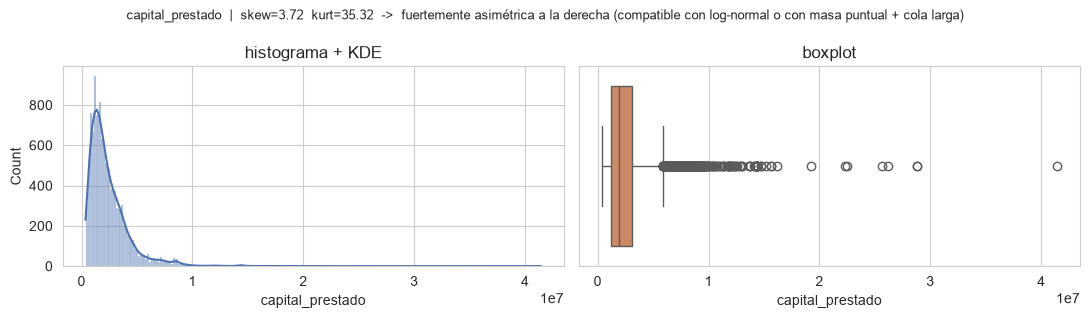

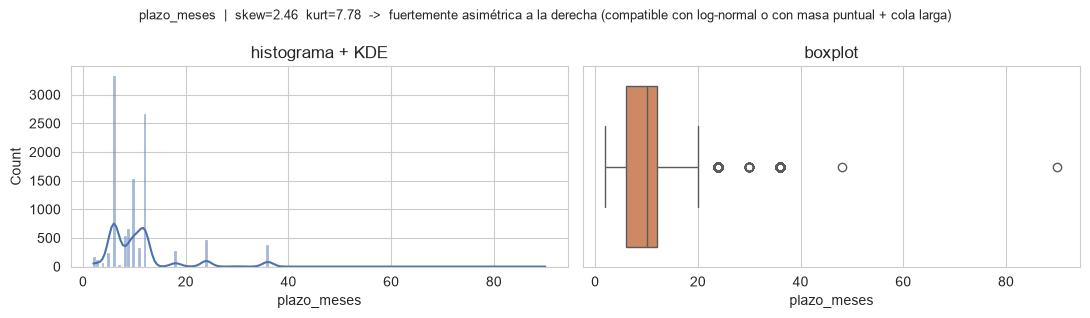

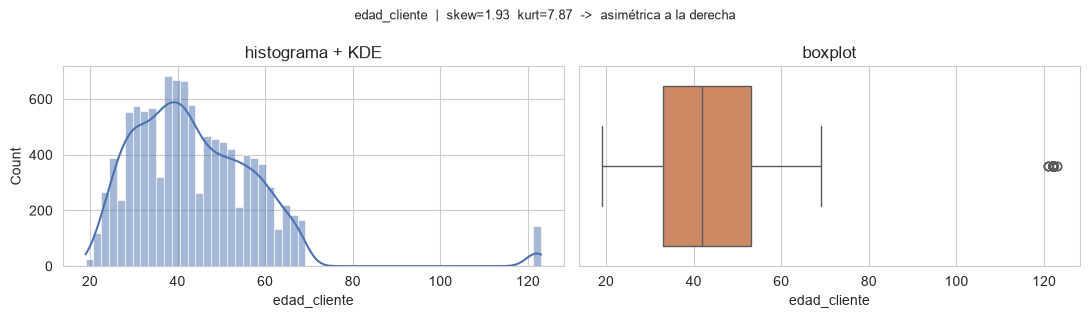

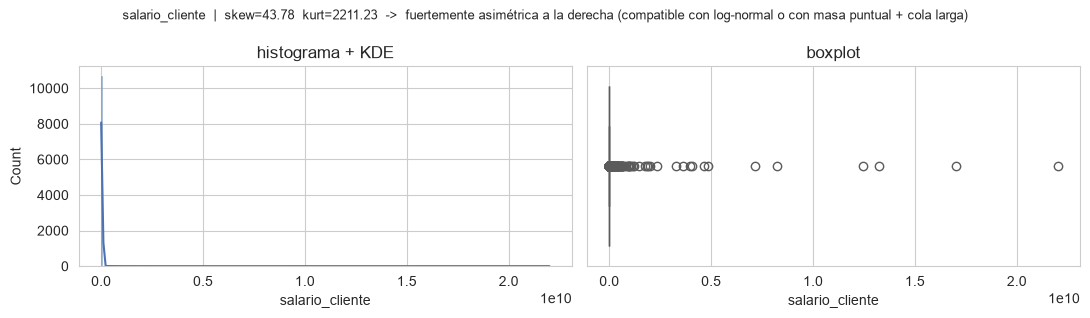

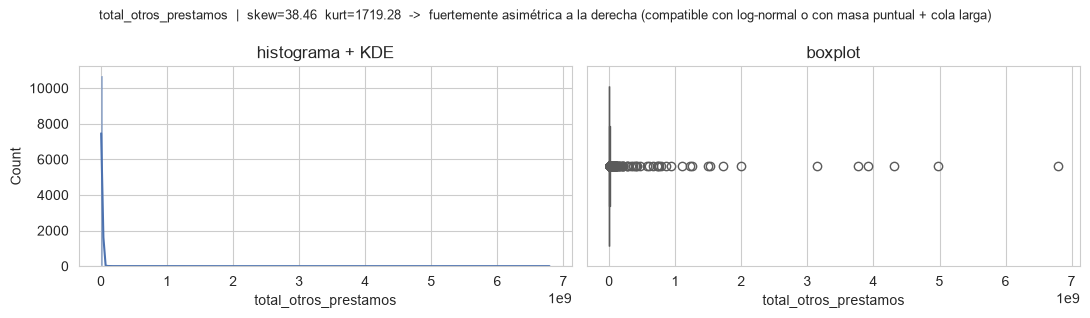

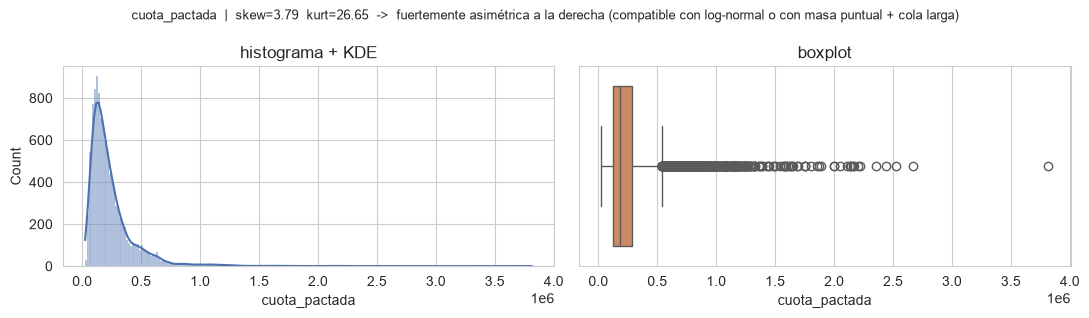

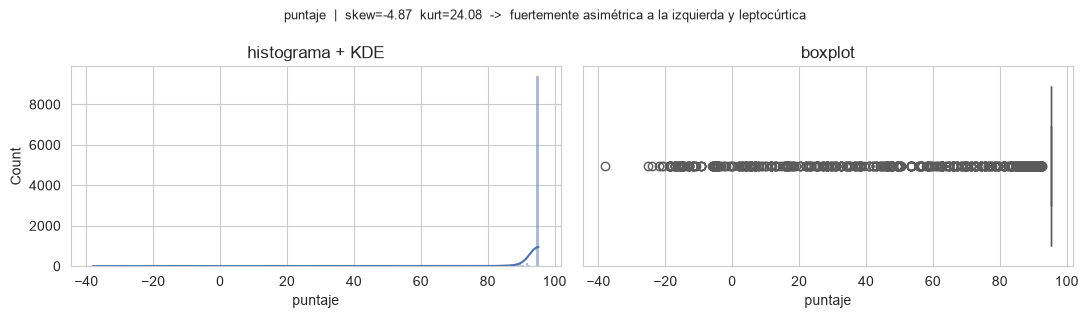

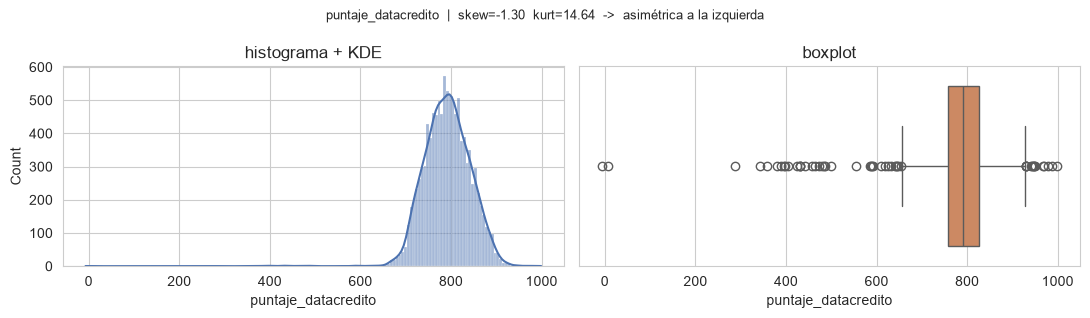

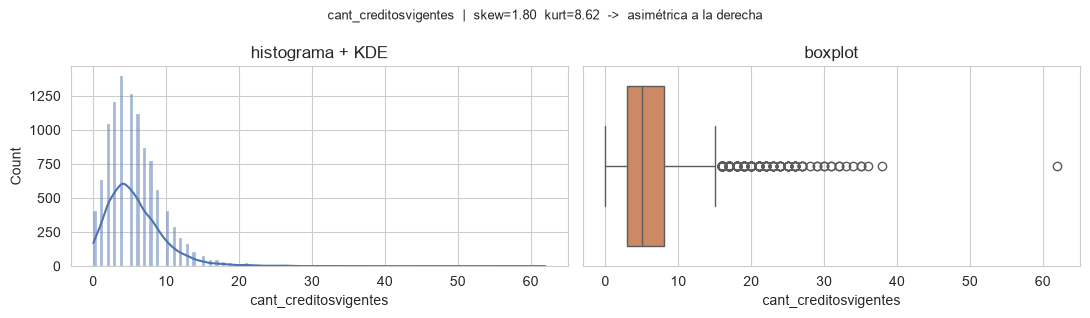

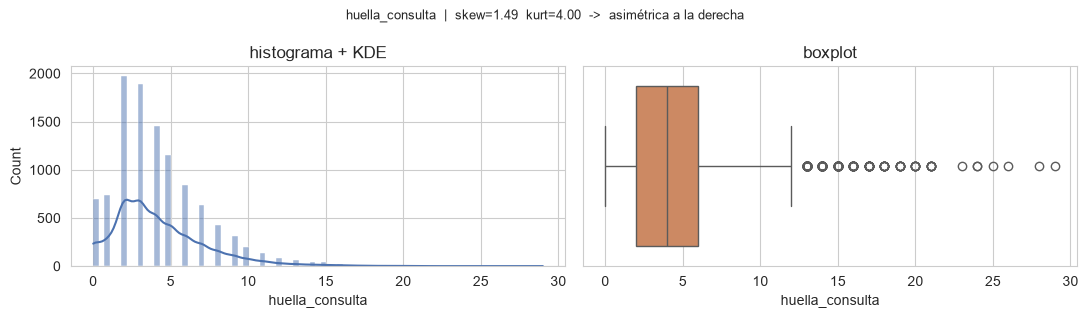

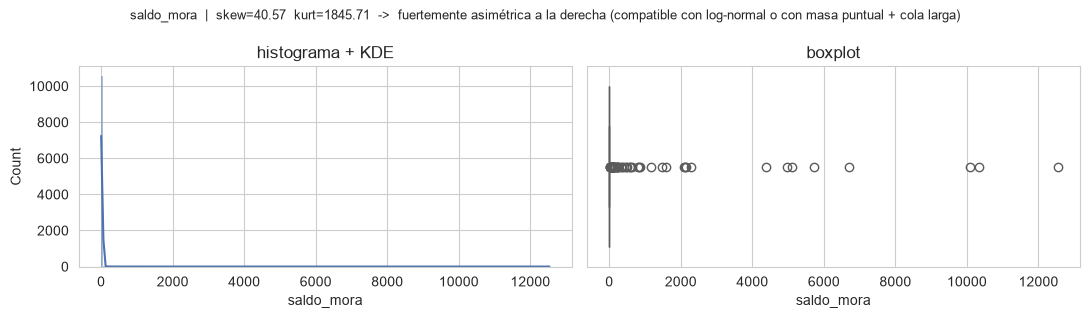

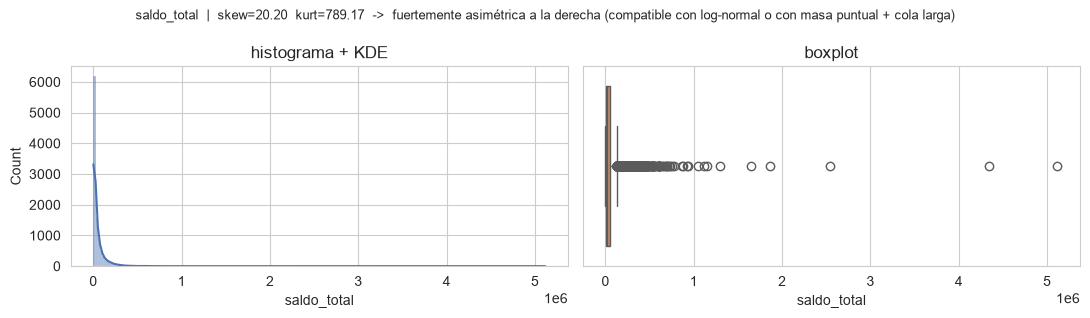

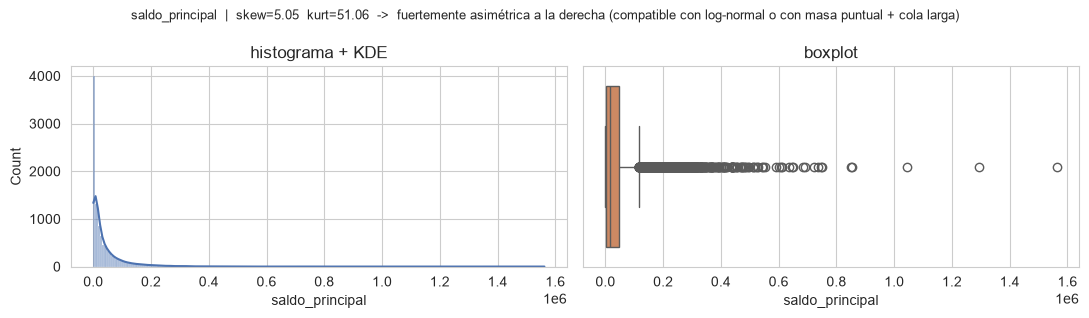

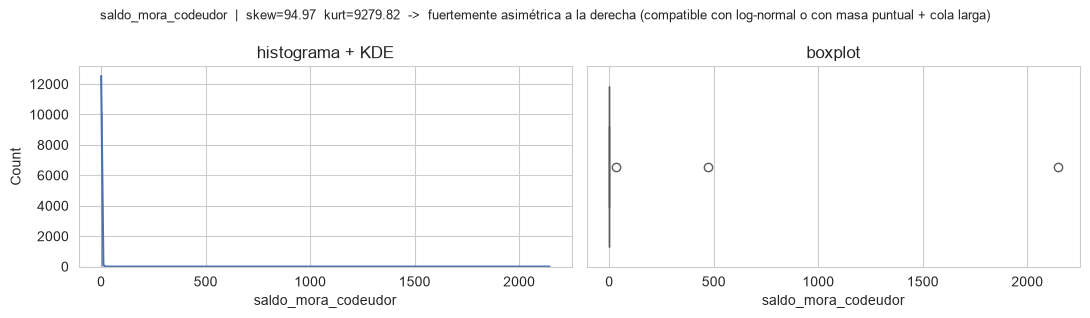

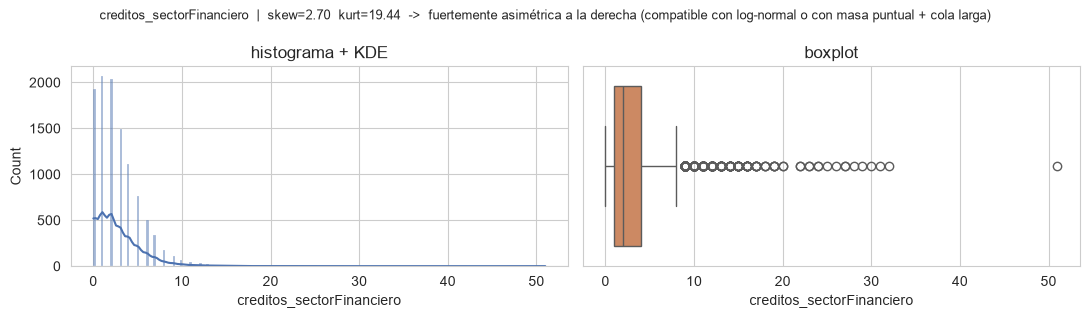

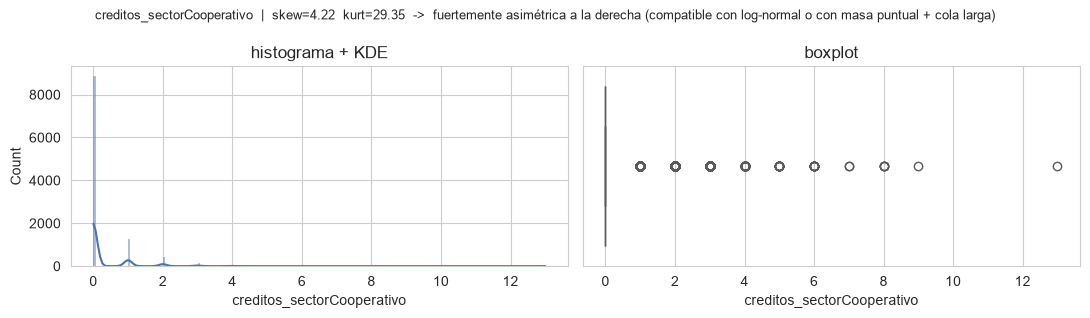

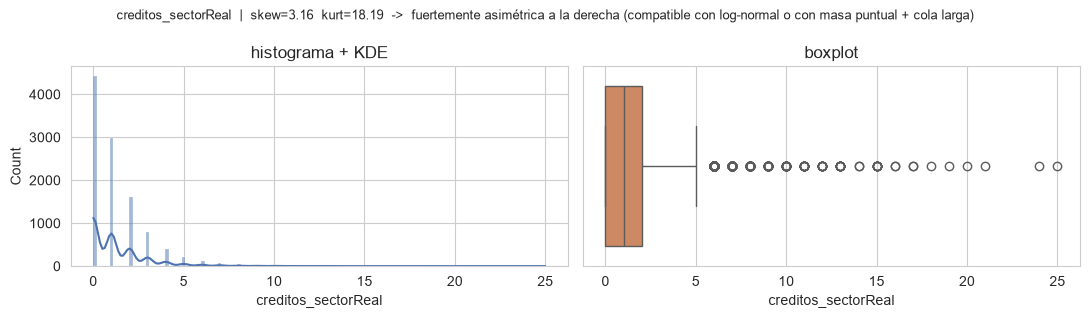

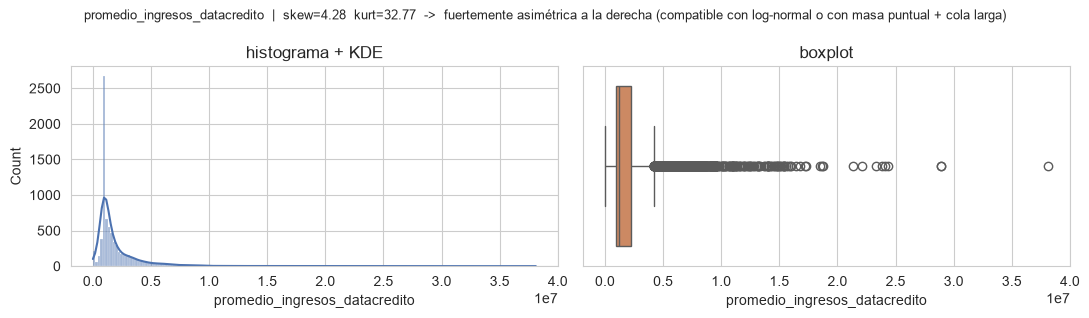

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


def calcular_estadisticas(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    return {
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "minimo": serie.min(),
        "maximo": serie.max(),
        "rango": serie.max() - serie.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "varianza": serie.var(),
        "desvio_std": serie.std(),
        "coef_variacion": (serie.std() / serie.mean()) if serie.mean() != 0 else np.nan,
        "skewness": serie.skew(),
        "kurtosis": serie.kurtosis(),
    }


def clasificar_distribucion(skew, kurt):
    if abs(skew) < 0.5 and abs(kurt) < 0.5:
        return "aproximadamente gaussiana"
    if skew >= 2 and kurt >= 5:
        return "fuertemente asimétrica a la derecha (compatible con log-normal o con masa puntual + cola larga)"
    if skew >= 0.5:
        return "asimétrica a la derecha"
    if skew <= -2 and kurt >= 5:
        return "fuertemente asimétrica a la izquierda y leptocúrtica"
    if skew <= -0.5:
        return "asimétrica a la izquierda"
    if kurt <= -1:
        return "platicúrtica, compatible con una distribución uniforme"
    return "aproximadamente simétrica, sin sesgo marcado"


resumen_numericas = []
for columna in VARIABLES_NUMERICAS:
    serie = df[columna].dropna()
    estadisticas = calcular_estadisticas(serie)
    estadisticas["columna"] = columna
    estadisticas["tipo_distribucion"] = clasificar_distribucion(
        estadisticas["skewness"], estadisticas["kurtosis"]
    )
    resumen_numericas.append(estadisticas)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title("histograma + KDE")
    sns.boxplot(x=serie, ax=axes[1], color="#DD8452")
    axes[1].set_title("boxplot")
    fig.suptitle(
        f"{columna}  |  skew={estadisticas['skewness']:.2f}  kurt={estadisticas['kurtosis']:.2f}"
        f"  ->  {estadisticas['tipo_distribucion']}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

Todos los estadísticos y la clasificación, en una sola tabla para poder comparar variables entre sí.

In [24]:
ORDEN_COLUMNAS = ["media", "mediana", "moda", "minimo", "maximo", "rango", "Q1", "Q3", "IQR",
                   "varianza", "desvio_std", "coef_variacion", "skewness", "kurtosis", "tipo_distribucion"]

tabla_resumen_numericas = pd.DataFrame(resumen_numericas).set_index("columna")[ORDEN_COLUMNAS]
tabla_resumen_numericas.iloc[:, :-1] = tabla_resumen_numericas.iloc[:, :-1].astype(float).round(2)
tabla_resumen_numericas

,media,mediana,moda,minimo,maximo,rango,Q1,Q3,IQR,varianza,desvio_std,coef_variacion,skewness,kurtosis,tipo_distribucion
columna,,,,,,,,,,,,,,,
capital_prestado,2434315.00,1921920.00,1200000.00,360000.00,4.144415e+07,4.108415e+07,1224831.00,3084840.00,1860009.00,3.646735e+12,1.909643e+06,0.78,3.72,35.32,fuertemente asimétrica a la derecha (compatibl...
plazo_meses,10.58,10.00,6.00,2.00,9.000000e+01,8.800000e+01,6.00,12.00,6.00,4.398000e+01,6.630000e+00,0.63,2.46,7.78,fuertemente asimétrica a la derecha (compatibl...
edad_cliente,43.95,42.00,40.00,19.00,1.230000e+02,1.040000e+02,33.00,53.00,20.00,2.268300e+02,1.506000e+01,0.34,1.93,7.87,asimétrica a la derecha
salario_cliente,17216431.46,3000000.00,3000000.00,0.00,2.200000e+10,2.200000e+10,2000000.00,4875808.00,2875808.00,1.263637e+17,3.554767e+08,20.65,43.78,2211.23,fuertemente asimétrica a la derecha (compatibl...
total_otros_prestamos,6238869.65,1000000.00,2000000.00,0.00,6.787675e+09,6.787675e+09,500000.00,2000000.00,1500000.00,1.402290e+16,1.184183e+08,18.98,38.46,1719.28,fuertemente asimétrica a la derecha (compatibl...
cuota_pactada,243617.41,182863.00,205990.00,23944.00,3.816752e+06,3.792808e+06,121041.50,287833.50,166792.00,4.430760e+10,2.104937e+05,0.86,3.79,26.65,fuertemente asimétrica a la derecha (compatibl...
puntaje,91.17,95.23,95.23,-38.01,9.523000e+01,1.332400e+02,95.23,95.23,0.00,2.711100e+02,1.647000e+01,0.18,-4.87,24.08,fuertemente asimétrica a la izquierda y leptoc...
puntaje_datacredito,791.46,792.00,783.00,-7.00,9.990000e+02,1.006000e+03,758.00,826.00,68.00,2.705190e+03,5.201000e+01,0.07,-1.30,14.64,asimétrica a la izquierda
cant_creditosvigentes,5.73,5.00,4.00,0.00,6.200000e+01,6.200000e+01,3.00,8.00,5.00,1.582000e+01,3.980000e+00,0.69,1.80,8.62,asimétrica a la derecha


**Interpretación.** Ninguna variable numérica es gaussiana; casi todas son fuertemente asimétricas a la derecha, típico de montos y conteos en riesgo crediticio (muchos casos "chicos", pocos casos grandes que estiran la cola): `capital_prestado`, `cuota_pactada`, `promedio_ingresos_datacredito`, `salario_cliente` y `total_otros_prestamos` se comportan como log-normales — y en las dos últimas la asimetría no es solo un efecto de un par de outliers: incluso sacando los valores por encima de 500 millones (que casi seguro son errores de carga, no salarios reales) el skewness sigue por encima de 18, así que la forma de fondo ya es fuertemente asimétrica.

`saldo_mora` y `saldo_mora_codeudor` no tienen una forma "de libro": son casi una masa puntual en 0 (ya vimos que rondan el 98-99.9% en cero) con una cola larga de valores en mora real — de ahí su kurtosis absurdamente alta (>1800 y >9000). `puntaje`, por su parte, sale fuertemente asimétrico **a la izquierda** (skew muy negativo, kurtosis alta): es el reflejo directo del valor de relleno que domina ~87% de las filas (visto en la sección anterior) empujando la distribución contra su techo, con una cola de valores bajos y negativos.

Las variables de conteo (`plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero/Cooperativo/Real`) son discretas y right-skewed, consistente con que la mayoría de los clientes tiene pocos créditos/consultas y unos pocos concentran valores altos.

## Outliers: IQR vs. z-score

Dos criterios estadísticos distintos, uno por columna, para comparar cuántos casos marca cada uno. Ninguno de los dos sabe de negocio: hace falta revisar manualmente qué valores están marcando para separar **outliers plausibles** (por ejemplo, un salario muy alto pero posible) de **valores imposibles** (por ejemplo, una edad de 123 años o un score negativo).

In [25]:
resumen_outliers = []
for columna in VARIABLES_NUMERICAS:
    serie = df[columna].dropna()

    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers_iqr = ((serie < lim_inf) | (serie > lim_sup)).sum()

    z = (serie - serie.mean()) / serie.std()
    outliers_z = (z.abs() > 3).sum()

    resumen_outliers.append({
        "columna": columna,
        "outliers_IQR": int(outliers_iqr),
        "pct_IQR": round(100 * outliers_iqr / len(serie), 2),
        "outliers_zscore": int(outliers_z),
        "pct_zscore": round(100 * outliers_z / len(serie), 2),
    })

tabla_outliers = pd.DataFrame(resumen_outliers).sort_values("outliers_IQR", ascending=False)
tabla_outliers

,columna,outliers_IQR,pct_IQR,outliers_zscore,pct_zscore
15,creditos_sectorCooperativo,1895,17.61,217,2.02
6,puntaje,1356,12.60,328,3.05
11,saldo_total,970,9.14,111,1.05
12,saldo_principal,951,9.18,219,2.11
1,plazo_meses,869,8.07,387,3.60
17,promedio_ingresos_datacredito,784,10.01,155,1.98
5,cuota_pactada,765,7.11,212,1.97
3,salario_cliente,718,6.67,20,0.19
4,total_otros_prestamos,589,5.47,26,0.24
0,capital_prestado,550,5.11,202,1.88


El criterio IQR es sistemáticamente más sensible que z-score en este dataset (marca más casos en casi todas las columnas): con distribuciones tan asimétricas, la media y el desvío estándar que usa z-score ya están inflados por la misma cola larga que se quiere detectar, así que z-score termina "acostumbrado" a la asimetría y deja pasar más casos. Ahora, algunos ejemplos puntuales para distinguir outlier plausible de valor imposible.

In [26]:
print(f"edad_cliente: máximo = {df['edad_cliente'].max()} años -> IMPOSIBLE, ningún cliente real tiene esa edad.")
print(f"puntaje: mínimo = {df['puntaje'].min():.2f} -> IMPOSIBLE, un score no puede ser negativo.")
print(f"puntaje_datacredito: mínimo = {df['puntaje_datacredito'].min():.0f}, máximo = {df['puntaje_datacredito'].max():.0f} "
      f"-> el mínimo negativo es IMPOSIBLE para un score de buró; el máximo de {df['puntaje_datacredito'].max():.0f} "
      f"también excede el techo habitual de este tipo de score.")

percentil_99_salario = df["salario_cliente"].quantile(0.99)
print(f"\nsalario_cliente: máximo = {df['salario_cliente'].max():,.0f} COP -> IMPOSIBLE como salario mensual real.")
print(f"salario_cliente: percentil 99 = {percentil_99_salario:,.0f} COP -> ALTO pero PLAUSIBLE "
      f"(un cliente de ingresos muy altos, no un error de carga; recién a partir del percentil 99.5 "
      f"({df['salario_cliente'].quantile(0.995):,.0f} COP) empieza a verse claramente imposible).")

edad_cliente: máximo = 123 años -> IMPOSIBLE, ningún cliente real tiene esa edad.
puntaje: mínimo = -38.01 -> IMPOSIBLE, un score no puede ser negativo.
puntaje_datacredito: mínimo = -7, máximo = 999 -> el mínimo negativo es IMPOSIBLE para un score de buró; el máximo de 999 también excede el techo habitual de este tipo de score.

salario_cliente: máximo = 22,000,000,000 COP -> IMPOSIBLE como salario mensual real.
salario_cliente: percentil 99 = 39,553,562 COP -> ALTO pero PLAUSIBLE (un cliente de ingresos muy altos, no un error de carga; recién a partir del percentil 99.5 (276,627,450 COP) empieza a verse claramente imposible).


## Variables categóricas: frecuencias

Para cada categórica: conteo absoluto y relativo, un countplot ordenado por frecuencia, y las categorías raras (menos del 1% de los casos).

=== tipo_credito ===
              conteo    pct
tipo_credito               
4               7747  71.98
9               2876  26.72
10               116   1.08
6                 21   0.20
7                  2   0.02
68                 1   0.01
Categorías raras (<1%): ['6', '7', '68']



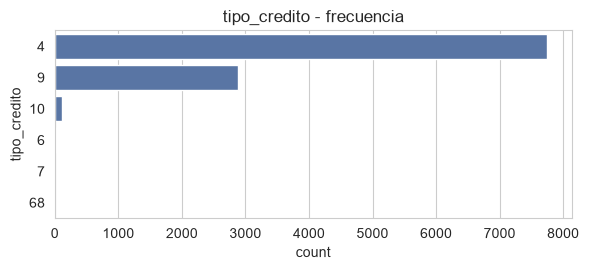

=== tipo_laboral ===
               conteo    pct
tipo_laboral                
Empleado         6754  62.75
Independiente    4009  37.25



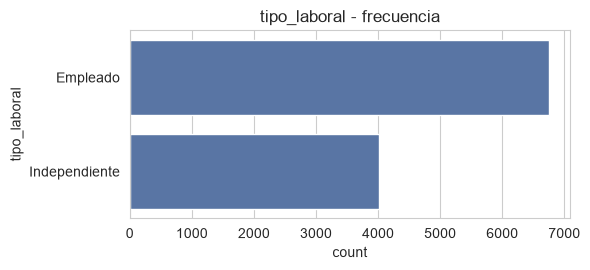

=== tendencia_ingresos ===
                    conteo    pct
tendencia_ingresos               
Creciente             5294  68.11
Decreciente           1291  16.61
Estable               1188  15.28



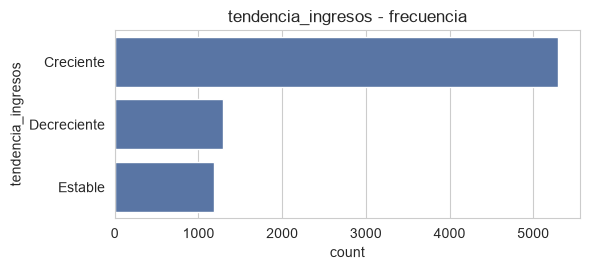

In [27]:
for columna in VARIABLES_CATEGORICAS:
    conteo_abs = df[columna].value_counts(dropna=True)
    conteo_rel = (df[columna].value_counts(normalize=True, dropna=True) * 100).round(2)
    tabla = pd.DataFrame({"conteo": conteo_abs, "pct": conteo_rel})
    print(f"=== {columna} ===")
    print(tabla)

    raras = tabla[tabla["pct"] < 1]
    if not raras.empty:
        print(f"Categorías raras (<1%): {list(raras.index)}")
    print()

    plt.figure(figsize=(6, 2.8))
    sns.countplot(data=df, y=columna, order=conteo_abs.index, color="#4C72B0")
    plt.title(f"{columna} - frecuencia")
    plt.tight_layout()
    plt.show()

**Interpretación.** `tipo_credito` está dominado por los códigos `4` (≈72%) y `9` (≈27%); el resto de los códigos (`10`, `6`, `7`, `68`) suman menos del 1.5% combinados, y `7` y `68` son casos aislados (una y dos filas) — `68` en particular llama la atención por no encajar con el resto de códigos (parecen de un dígito), posible error de captura a revisar, no a borrar todavía. `tipo_laboral` es una dicotómica balanceada razonablemente (mayoría `Empleado`). `tendencia_ingresos` (ya sin los valores fuera de dominio, unificados a NaN en la sección anterior) está dominada por `Creciente`, con `Decreciente` y `Estable` como categorías minoritarias pero no raras.

## Variable objetivo: `Pago_atiempo`

Análisis aparte porque es la variable a predecir: acá el desbalance de clases importa para decidir cómo modelar y qué métrica usar, no para decidir si la columna es "rara".

              conteo    pct
Pago_atiempo               
1              10252  95.25
0                511   4.75


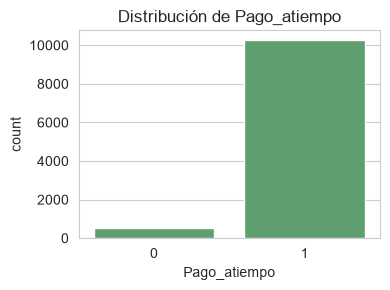

In [28]:
conteo_pago = df["Pago_atiempo"].value_counts()
pct_pago = (df["Pago_atiempo"].value_counts(normalize=True) * 100).round(2)
tabla_pago = pd.DataFrame({"conteo": conteo_pago, "pct": pct_pago})
print(tabla_pago)

plt.figure(figsize=(4, 3))
sns.countplot(data=df, x="Pago_atiempo", color="#55A868")
plt.title("Distribución de Pago_atiempo")
plt.tight_layout()
plt.show()

**Interpretación.** La clase `1` (pagó a tiempo) concentra alrededor del 95% de los créditos, contra apenas ~5% de la clase `0`. Es un desbalance fuerte, no un detalle menor: un modelo que prediga siempre "pagó a tiempo" ya acertaría ~95% de las veces sin aprender nada útil, así que el **accuracy no sirve** como métrica principal. Para modelar esto va a hacer falta mirar precision/recall/F1 de la clase minoritaria (el no-pago, que es la que realmente le importa al negocio), curvas precision-recall (mejor que ROC-AUC con este nivel de desbalance), y probablemente técnicas de manejo de desbalance (`class_weight`, sobremuestreo/submuestreo, o ambos) más una partición estratificada de train/test.

## Tablas pivote

Dos tablas que resumen una numérica agregada por una categórica, con conteo y media, para empezar a ver si el tipo de crédito o la situación laboral se asocian con montos distintos.

In [29]:
pivot_capital_por_tipo_credito = df.pivot_table(
    index="tipo_credito", values="capital_prestado", aggfunc=["count", "mean"]
)
pivot_capital_por_tipo_credito.columns = ["conteo", "capital_prestado_promedio"]
pivot_capital_por_tipo_credito.sort_values("conteo", ascending=False)

,conteo,capital_prestado_promedio
tipo_credito,,
4,7747,2.414644e+06
9,2876,2.445491e+06
10,116,3.292477e+06
6,21,2.860483e+06
7,2,8.117212e+06
68,1,2.822824e+06


In [30]:
pivot_salario_por_tipo_laboral = df.pivot_table(
    index="tipo_laboral", values="salario_cliente", aggfunc=["count", "mean"]
)
pivot_salario_por_tipo_laboral.columns = ["conteo", "salario_promedio"]
pivot_salario_por_tipo_laboral

,conteo,salario_promedio
tipo_laboral,,
Empleado,6754,2.134964e+07
Independiente,4009,1.025317e+07


**Interpretación.** El capital promedio varía según `tipo_credito` (se ve en la tabla pivote), aunque los tipos con muy pocas filas (`7`, `68`) no son representativos y su promedio no debería sobreinterpretarse. En `salario_cliente` por `tipo_laboral`, el promedio de `Empleado` queda inflado por los mismos valores extremos (miles de millones) vistos en la sección de outliers: 36 de los 37 salarios por encima de 500 millones son de clientes `Empleado`, no `Independiente`. Sin esos extremos, los promedios de ambos grupos son mucho más parecidos (~5.2M vs ~4.8M COP) — un motivo más para tratar esos valores antes de sacar conclusiones de negocio sobre esta comparación.

# Análisis bivariable y multivariable

Todo el análisis bivariable se hace **contra la variable objetivo** `Pago_atiempo`, que es lo que finalmente importa para el modelo. El multivariable mira relaciones entre las variables explicativas entre sí (correlaciones, multicolinealidad, combinaciones de más de dos variables).

## Numéricas vs. `Pago_atiempo`

Para cada variable numérica: boxplot y violinplot separados por clase (el violinplot suma la forma de la distribución, que el boxplot no muestra), y una tabla con media y mediana por clase más la diferencia relativa entre clases — con 95%/5% de desbalance, mirar la diferencia relativa importa más que la absoluta.

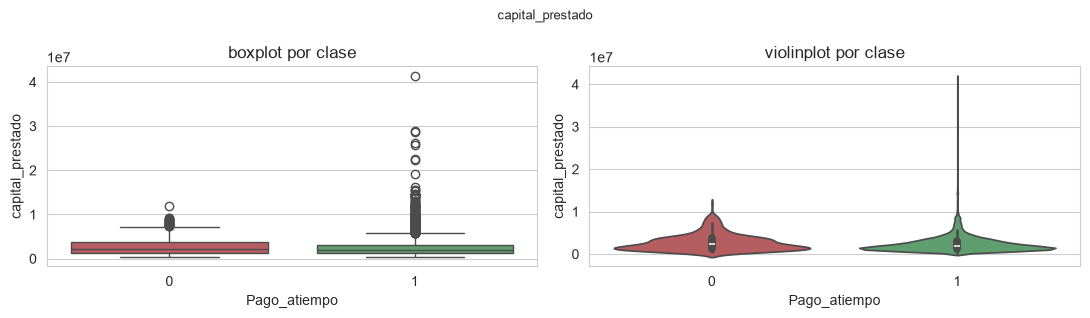

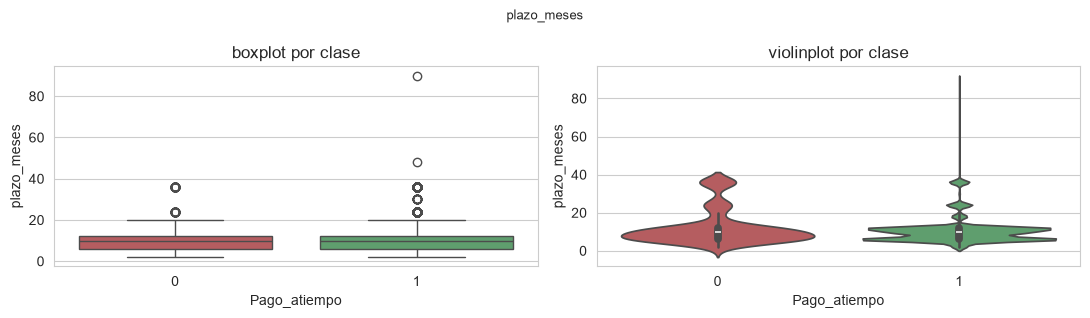

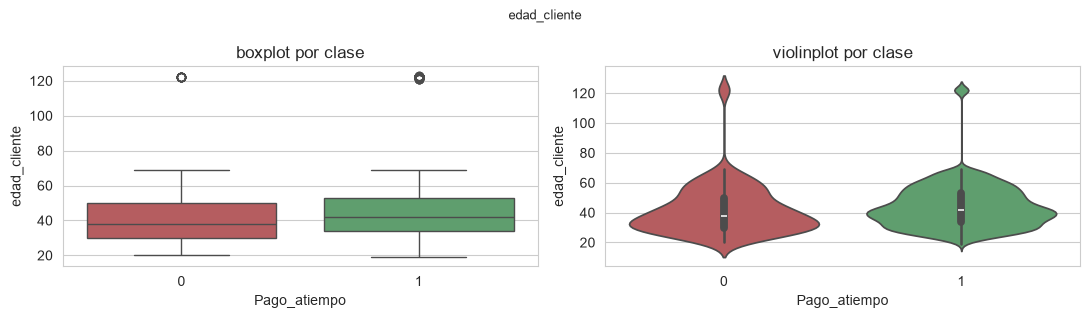

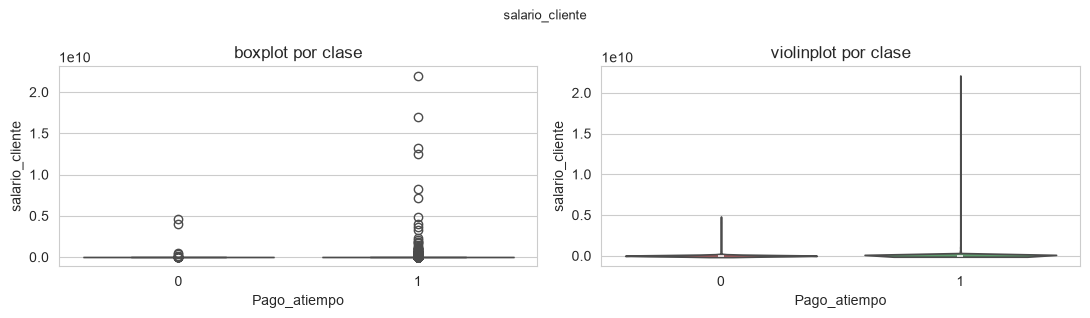

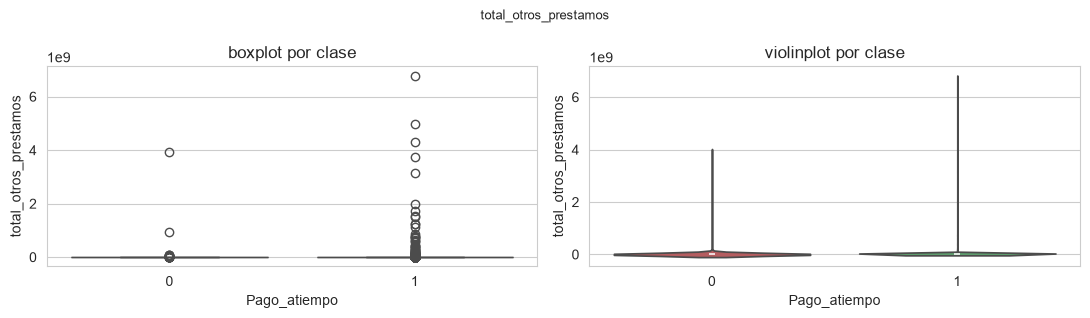

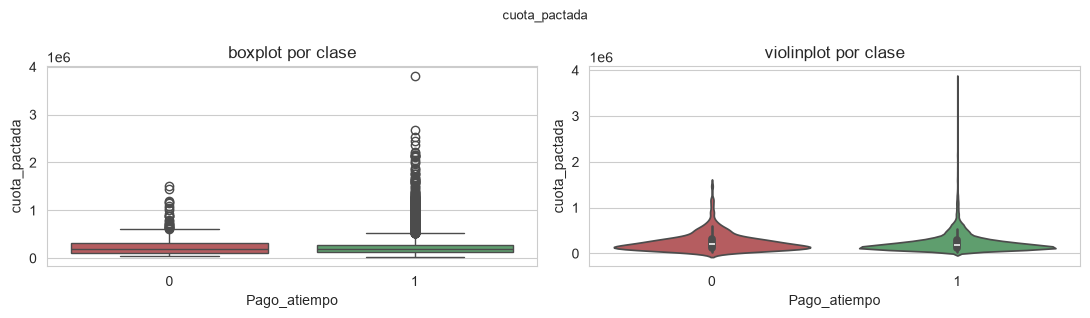

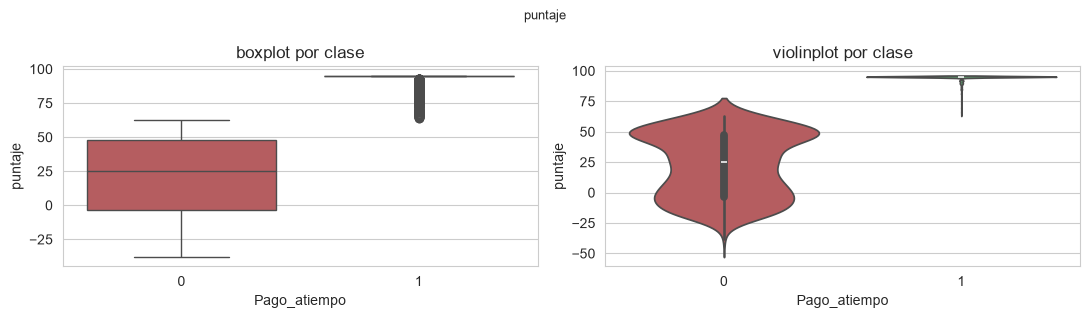

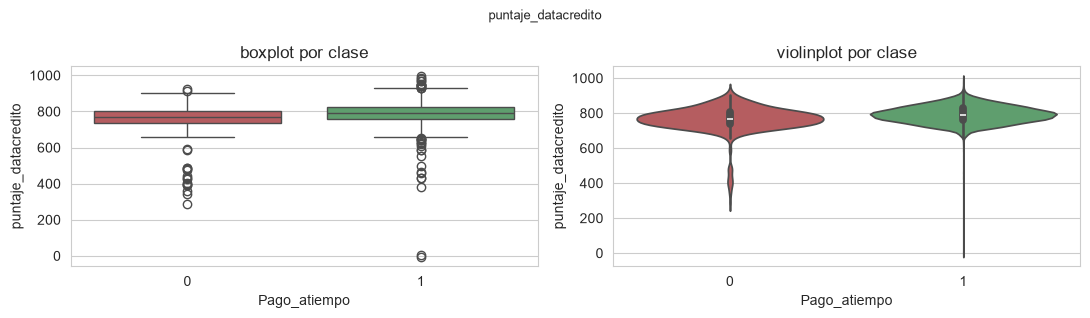

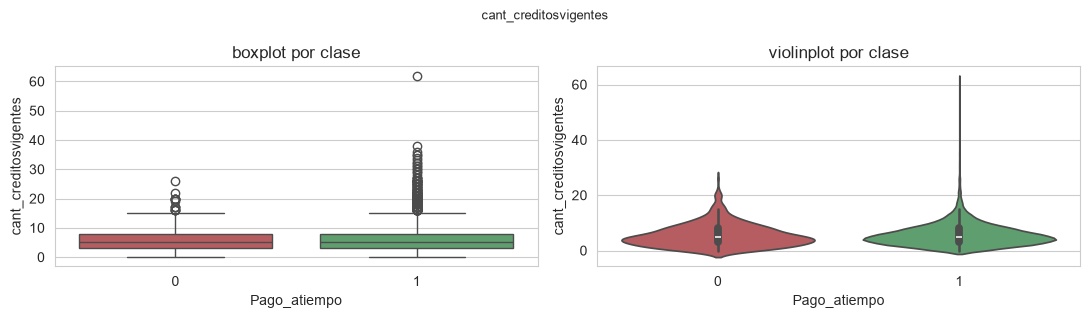

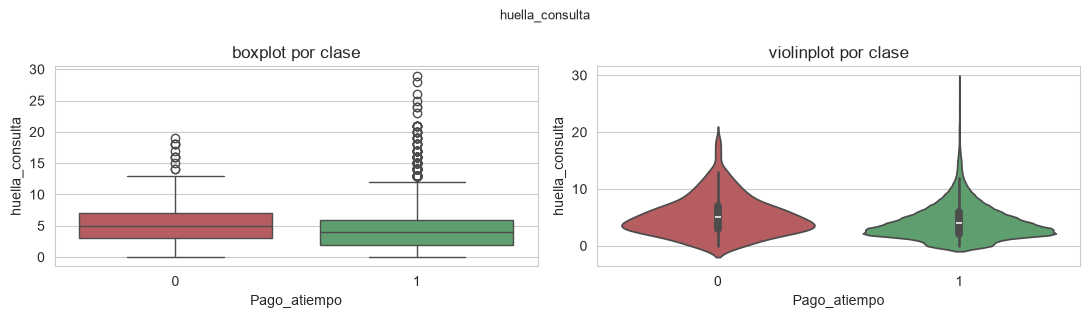

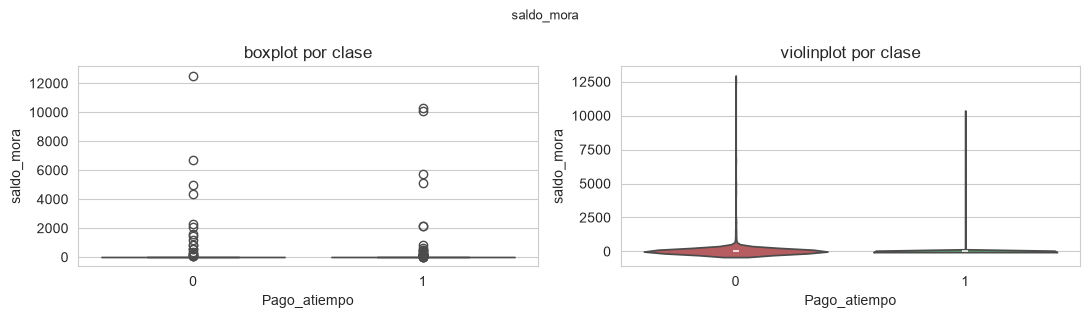

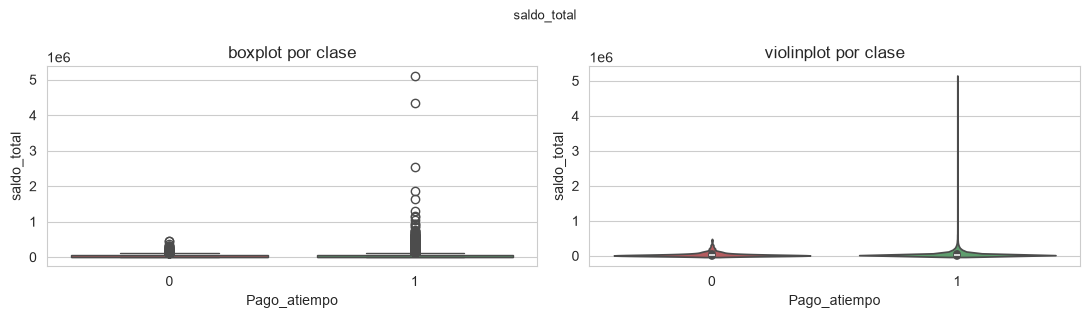

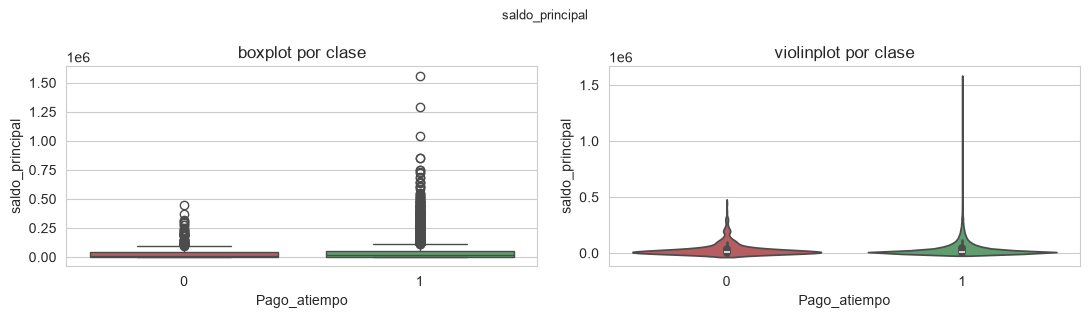

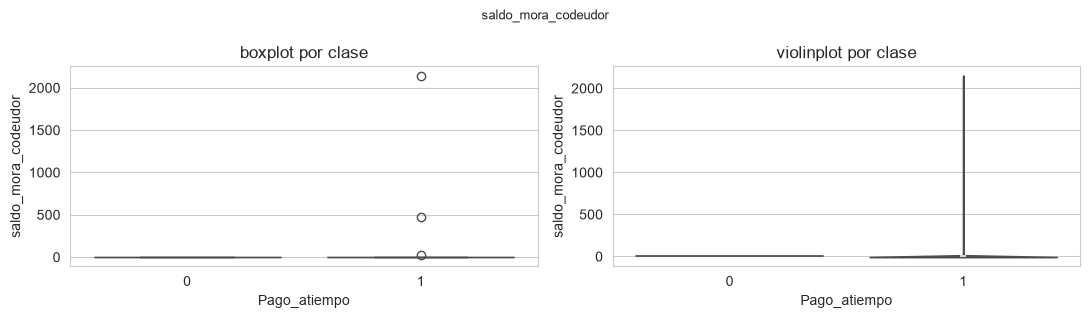

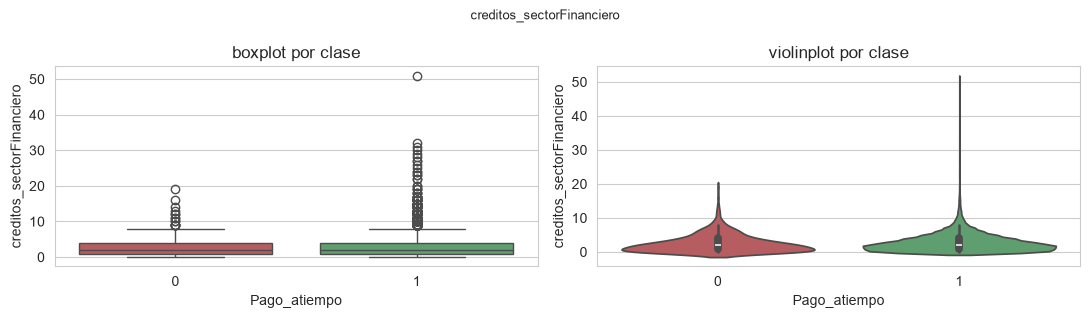

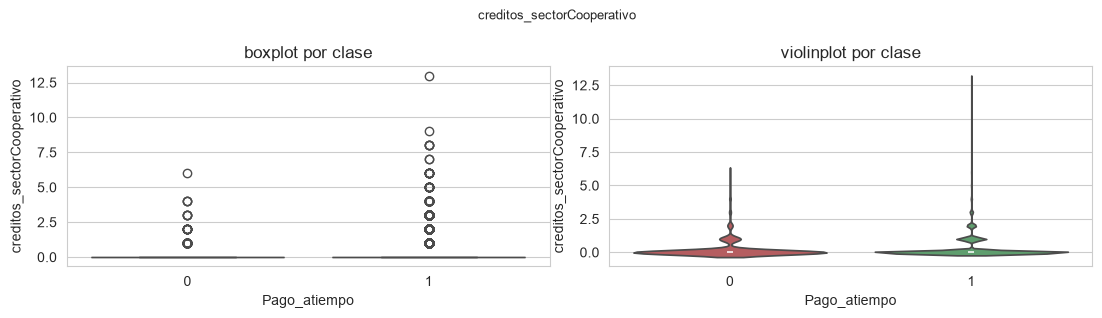

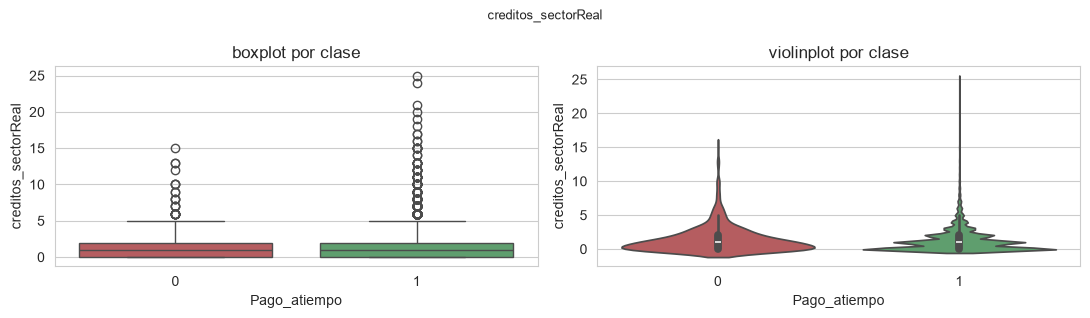

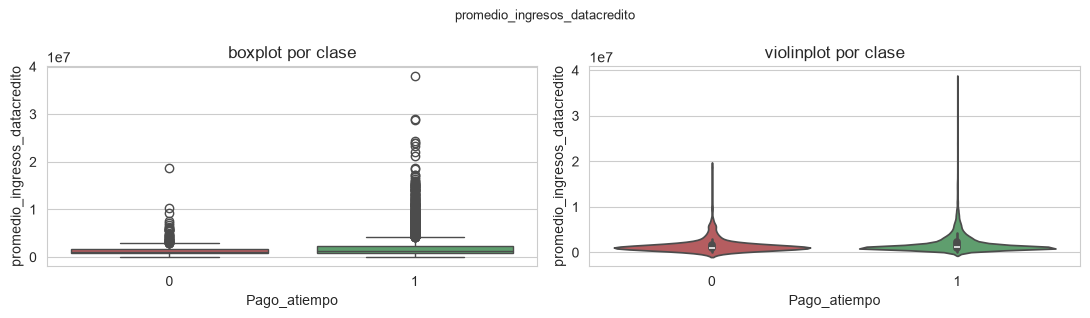

In [31]:
resumen_bivariable_num = []
for columna in VARIABLES_NUMERICAS:
    datos = df[[columna, "Pago_atiempo"]].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    sns.boxplot(data=datos, x="Pago_atiempo", y=columna, ax=axes[0], hue="Pago_atiempo",
                palette={0: "#C44E52", 1: "#55A868"}, legend=False)
    axes[0].set_title("boxplot por clase")
    sns.violinplot(data=datos, x="Pago_atiempo", y=columna, ax=axes[1], hue="Pago_atiempo",
                    palette={0: "#C44E52", 1: "#55A868"}, legend=False)
    axes[1].set_title("violinplot por clase")
    fig.suptitle(columna, fontsize=9)
    plt.tight_layout()
    plt.show()

    media_0 = datos.loc[datos["Pago_atiempo"] == 0, columna].mean()
    media_1 = datos.loc[datos["Pago_atiempo"] == 1, columna].mean()
    mediana_0 = datos.loc[datos["Pago_atiempo"] == 0, columna].median()
    mediana_1 = datos.loc[datos["Pago_atiempo"] == 1, columna].median()
    diff_relativa = ((media_1 - media_0) / abs(media_0) * 100) if media_0 != 0 else np.nan

    resumen_bivariable_num.append({
        "columna": columna,
        "media_clase_0": media_0,
        "media_clase_1": media_1,
        "mediana_clase_0": mediana_0,
        "mediana_clase_1": mediana_1,
        "dif_relativa_medias_pct": diff_relativa,
    })

In [32]:
tabla_bivariable_num = pd.DataFrame(resumen_bivariable_num).set_index("columna").round(2)
tabla_bivariable_num.sort_values("dif_relativa_medias_pct", key=abs, ascending=False)

,media_clase_0,media_clase_1,mediana_clase_0,mediana_clase_1,dif_relativa_medias_pct
columna,,,,,
puntaje,23.09,94.56,25.42,95.23,309.52
saldo_mora,82.37,4.05,0.00,0.00,-95.08
total_otros_prestamos,11564401.93,5973424.18,900000.00,1000000.00,-48.35
creditos_sectorCooperativo,0.20,0.27,0.00,0.00,35.55
salario_cliente,23555143.33,16900485.13,3000000.00,3000000.00,-28.25
promedio_ingresos_datacredito,1605742.05,2023447.77,1052529.00,1211296.00,26.01
huella_consulta,5.24,4.18,5.00,4.00,-20.28
saldo_total,39074.92,46276.90,14518.50,16308.00,18.43
plazo_meses,12.45,10.48,10.00,10.00,-15.81


**Interpretación.** `puntaje` es, a simple vista, la variable que más separa las dos clases: su boxplot/violinplot por clase prácticamente no se superponen, la clase `1` está pegada al valor de relleno (~95.23) y la clase `0` se desparrama hacia valores bajos y negativos. El resto de las numéricas muestra diferencias de medias/medianas entre clases bastante chicas — coherente con el desbalance 95/5 y con lo que va a confirmar el ranking del punto 3.

**Cuidado al leer la columna `dif_relativa_medias_pct`:** no es una medida de separación de clases por sí sola. `creditos_sectorCooperativo`, por ejemplo, aparece con una diferencia relativa alta (~36%) aunque en el ranking del punto 3 queda muy abajo (point-biserial ≈ 0.02) — el porcentaje es grande porque su media es casi cero en ambas clases (0.20 vs 0.27), y un salto relativo grande sobre una base minúscula no implica que la variable separe bien. Para eso sirve el ranking del punto 3, que sí pondera la variabilidad dentro de cada clase.

## Categóricas vs. `Pago_atiempo`

Para cada categórica: tabla cruzada con porcentaje **por fila** (para comparar tasas de pago a tiempo entre categorías, no volúmenes), barras apiladas al 100%, y test chi-cuadrado de independencia con su p-valor (H0: la categórica y `Pago_atiempo` son independientes).

=== tipo_credito (chi2=68.86, p-valor=1.772e-13) ===
Pago_atiempo      0       1
tipo_credito               
10             2.59   97.41
4              4.69   95.31
6             42.86   57.14
68             0.00  100.00
7              0.00  100.00
9              4.73   95.27



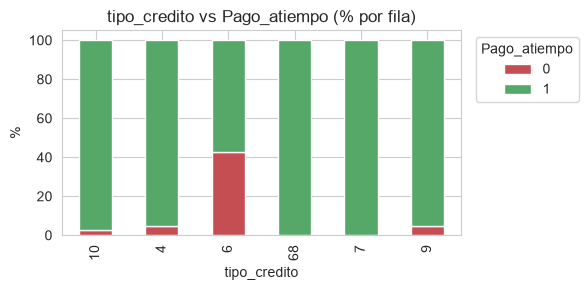

=== tipo_laboral (chi2=8.00, p-valor=0.004686) ===
Pago_atiempo      0      1
tipo_laboral              
Empleado       4.29  95.71
Independiente  5.51  94.49



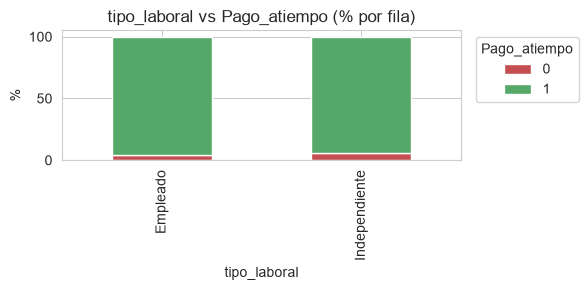

=== tendencia_ingresos (chi2=13.91, p-valor=0.0009543) ===
Pago_atiempo           0      1
tendencia_ingresos             
Decreciente         6.27  93.73
Estable             4.63  95.37
Creciente           3.91  96.09



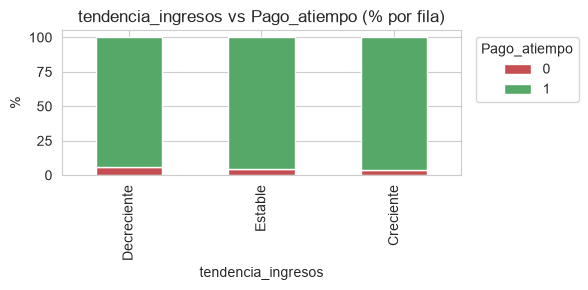

,columna,chi2,p_valor,gl
0,tipo_credito,68.856727,1.772029e-13,5
1,tipo_laboral,7.996823,4.685950e-03,1
2,tendencia_ingresos,13.909123,9.542725e-04,2


In [33]:
from scipy.stats import chi2_contingency

resumen_chi2 = []
for columna in VARIABLES_CATEGORICAS:
    tabla_cruzada = pd.crosstab(df[columna], df["Pago_atiempo"])
    tabla_pct = pd.crosstab(df[columna], df["Pago_atiempo"], normalize="index") * 100

    chi2, p_valor, dof, esperado = chi2_contingency(tabla_cruzada)
    resumen_chi2.append({"columna": columna, "chi2": chi2, "p_valor": p_valor, "gl": dof})

    print(f"=== {columna} (chi2={chi2:.2f}, p-valor={p_valor:.4g}) ===")
    print(tabla_pct.round(2))
    print()

    tabla_pct.plot(kind="bar", stacked=True, figsize=(6, 3),
                    color={0: "#C44E52", 1: "#55A868"})
    plt.title(f"{columna} vs Pago_atiempo (% por fila)")
    plt.ylabel("%")
    plt.legend(title="Pago_atiempo", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

pd.DataFrame(resumen_chi2)

**Interpretación.** Los tres p-valores dan por debajo de 0.05: con un dataset de más de 10.000 filas, hasta asociaciones chicas resultan "estadísticamente significativas", así que el p-valor solo dice que la asociación no es cero — no dice que sea fuerte. Mirando las barras apiladas, la tasa de pago a tiempo se mantiene arriba del 90% en casi todas las categorías de las tres variables; no aparece ninguna categoría que hunda claramente la tasa de pago, más allá de diferencias de unos pocos puntos porcentuales. Esto es consistente con los Cramér's V (bajos) que se calculan en el ranking siguiente.

## Ranking: qué tanto separa cada variable a las clases

Para poder comparar variables numéricas y categóricas en una sola tabla se usan dos medidas de asociación, ambas acotadas aproximadamente en [0, 1] en valor absoluto y con la misma lectura ("cuánto más lejos de 0, más separa"): **correlación punto-biserial** (equivalente a Pearson entre la numérica y el 0/1 de `Pago_atiempo`) para las numéricas, y **Cramér's V** para las categóricas. No son la misma escala matemática, así que la comparación es aproximada, no exacta — se aclara explícitamente por transparencia metodológica.

In [34]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, dof, esperado = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


ranking = []
for columna in VARIABLES_NUMERICAS:
    valor = df[columna].corr(df["Pago_atiempo"])
    ranking.append({"columna": columna, "tipo": "numérica", "medida": "point-biserial", "valor": valor})

for columna in VARIABLES_CATEGORICAS:
    valor = cramers_v(df[columna], df["Pago_atiempo"])
    ranking.append({"columna": columna, "tipo": "categórica", "medida": "Cramér's V", "valor": valor})

tabla_ranking = pd.DataFrame(ranking)
tabla_ranking["valor_abs"] = tabla_ranking["valor"].abs()
tabla_ranking = tabla_ranking.sort_values("valor_abs", ascending=False).drop(columns="valor_abs")
tabla_ranking["valor"] = tabla_ranking["valor"].round(4)
tabla_ranking.reset_index(drop=True)

,columna,tipo,medida,valor
0,puntaje,numérica,point-biserial,0.9231
1,puntaje_datacredito,numérica,point-biserial,0.1180
2,tipo_credito,categórica,Cramér's V,0.0800
3,huella_consulta,numérica,point-biserial,-0.0737
4,saldo_mora,numérica,point-biserial,-0.0735
5,plazo_meses,numérica,point-biserial,-0.0631
6,tendencia_ingresos,categórica,Cramér's V,0.0423
7,capital_prestado,numérica,point-biserial,-0.0406
8,promedio_ingresos_datacredito,numérica,point-biserial,0.0399
9,edad_cliente,numérica,point-biserial,0.0323


**Las 5 más prometedoras:** `puntaje`, `puntaje_datacredito`, `tipo_credito`, `huella_consulta` y `saldo_mora`.

`puntaje` domina el ranking por lejos (point-biserial ≈ 0.92, el siguiente ni llega a 0.12). Esto **no es necesariamente una buena noticia**: una correlación así de alta con el objetivo, en una variable que en la sección anterior ya mostró un valor de relleno dominando el 87% de los casos, es la señal típica de **fuga de información (data leakage)** — `puntaje` podría estar calculado con información posterior al desenlace del crédito, o directamente ser una proxy casi 1 a 1 del resultado. Antes de usarla como feature del modelo hay que confirmar con el área de negocio en qué momento se calcula ese score, porque si no está disponible en el momento de originar el crédito, no se puede usar para predecir.

**Las 5 que no aportan nada:** `salario_cliente`, `saldo_mora_codeudor`, `cant_creditosvigentes`, `total_otros_prestamos` y `saldo_principal`, todas con |valor| por debajo de 0.012 — prácticamente sin relación individual con `Pago_atiempo`. Eso no significa que sean inútiles para el modelo (pueden aportar en combinación con otras), solo que aisladas no separan nada.

## `fecha_prestamo` vs. `Pago_atiempo`: tendencia temporal

Tasa de pago a tiempo por mes de originación del crédito, para ver si hay tendencia o estacionalidad. Se grafica junto con la cantidad de créditos por mes, porque una tasa calculada sobre pocos casos es poco confiable y no debería leerse igual que una calculada sobre miles.

In [35]:
df["mes_prestamo"] = df["fecha_prestamo"].dt.to_period("M")
tasa_mensual = df.groupby("mes_prestamo", observed=True)["Pago_atiempo"].agg(["mean", "count"])
tasa_mensual["mean"] = (tasa_mensual["mean"] * 100).round(2)
tasa_mensual.columns = ["tasa_pago_atiempo_pct", "cant_creditos"]
tasa_mensual

,tasa_pago_atiempo_pct,cant_creditos
mes_prestamo,,
2024-11,93.01,186
2024-12,93.91,1216
2025-01,95.51,1917
2025-02,94.15,1094
2025-03,94.89,1115
2025-04,93.74,1102
2025-05,95.66,1083
2025-06,96.24,665
2025-07,96.89,644


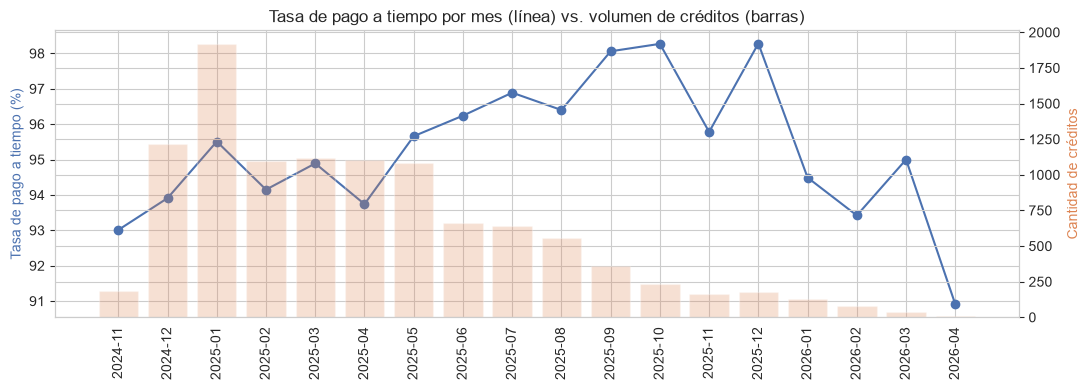

In [36]:
fig, ax1 = plt.subplots(figsize=(11, 4))
x = tasa_mensual.index.astype(str)
ax1.plot(x, tasa_mensual["tasa_pago_atiempo_pct"], marker="o", color="#4C72B0")
ax1.set_ylabel("Tasa de pago a tiempo (%)", color="#4C72B0")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.bar(x, tasa_mensual["cant_creditos"], alpha=0.25, color="#DD8452")
ax2.set_ylabel("Cantidad de créditos", color="#DD8452")

plt.title("Tasa de pago a tiempo por mes (línea) vs. volumen de créditos (barras)")
plt.tight_layout()
plt.show()

**Interpretación.** La tasa de pago a tiempo se mueve en un rango relativamente angosto (~91%-98%) con una tendencia levemente ascendente desde fines de 2024 hasta mediados/fines de 2025. Los últimos meses de la serie (2026-01 en adelante) muestran valores más ruidosos, pero coinciden con los meses de **menor volumen** (127, 76, 40 y 11 créditos respectivamente, contra más de 1.000 créditos por mes en el pico de la serie) — con tan pocos casos, una tasa que "baja" ahí no es necesariamente una tendencia real, es ruido estadístico. No hay una estacionalidad clara (no se repite un patrón mes a mes entre años, porque además solo hay datos de una parte de un segundo año).

# Análisis multivariable

Ahora se mira cómo se relacionan las variables explicativas **entre sí**, no contra el objetivo: correlaciones, riesgo de multicolinealidad, y combinaciones de tres o más variables.

## Correlación de Pearson y de Spearman

Pearson mide relación **lineal** y es sensible a outliers; Spearman mide relación **monótona** (por rangos) y es robusto a outliers y a relaciones no lineales. Con variables tan asimétricas y con outliers tan extremos como las de este dataset (visto en el análisis univariable), ambas pueden dar resultados bastante distintos entre sí — por eso conviene mirar las dos, no solo una.

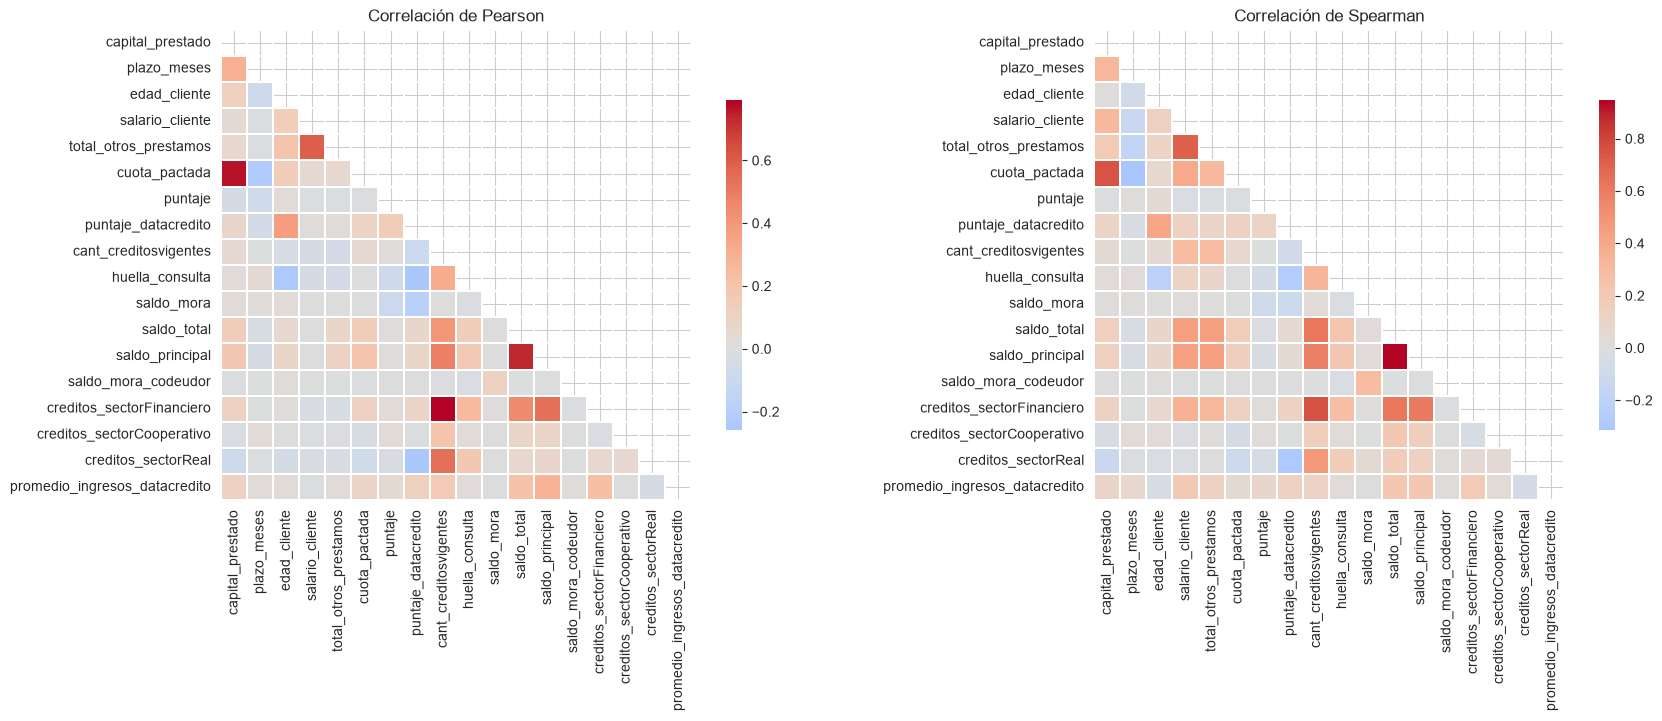

In [37]:
corr_pearson = df[VARIABLES_NUMERICAS].corr(method="pearson")
corr_spearman = df[VARIABLES_NUMERICAS].corr(method="spearman")

mascara = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_pearson, mask=mascara, cmap="coolwarm", center=0, ax=axes[0],
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
axes[0].set_title("Correlación de Pearson")
sns.heatmap(corr_spearman, mask=mascara, cmap="coolwarm", center=0, ax=axes[1],
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
axes[1].set_title("Correlación de Spearman")
plt.tight_layout()
plt.show()

In [38]:
print("saldo_total vs saldo_principal:")
print(f"  Pearson  = {corr_pearson.loc['saldo_total', 'saldo_principal']:.3f}")
print(f"  Spearman = {corr_spearman.loc['saldo_total', 'saldo_principal']:.3f}")

saldo_total vs saldo_principal:
  Pearson  = 0.735
  Spearman = 0.946


**Dónde difieren en este dataset.** El ejemplo más claro es `saldo_total` vs. `saldo_principal`: Pearson da ≈0.74 y Spearman ≈0.95. La relación real entre las dos es casi monótona perfecta (donde una es alta la otra también lo es, prácticamente siempre — tiene sentido de negocio, el saldo principal es la mayor parte del saldo total), pero unos pocos valores extremos (los mismos outliers vistos en el univariable) estiran la nube de puntos y "ensucian" la métrica lineal. Spearman, al trabajar con rangos en lugar de valores, no se deja arrastrar por esos extremos y muestra la relación real con más fidelidad.

## Pares con correlación absoluta > 0.8 (riesgo de multicolinealidad)

Se revisan ambas matrices completas, y además, puntualmente, la familia `saldo_*` y el trío `capital_prestado`/`cuota_pactada`/`plazo_meses`, que están relacionados por construcción (un crédito define su cuota a partir del capital y el plazo).

In [39]:
pares_alta_corr = []
for i in range(len(VARIABLES_NUMERICAS)):
    for j in range(i + 1, len(VARIABLES_NUMERICAS)):
        a, b = VARIABLES_NUMERICAS[i], VARIABLES_NUMERICAS[j]
        p = corr_pearson.loc[a, b]
        s = corr_spearman.loc[a, b]
        if abs(p) > 0.8 or abs(s) > 0.8:
            pares_alta_corr.append({"var_a": a, "var_b": b, "pearson": round(p, 3), "spearman": round(s, 3)})

tabla_multicolinealidad = pd.DataFrame(pares_alta_corr)
print("Pares con |corr| > 0.8 en Pearson y/o Spearman:")
print(tabla_multicolinealidad if not tabla_multicolinealidad.empty else "Ninguno")

print("\nFamilia saldo_*:")
familia_saldo = ["saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor"]
print("Pearson:\n", corr_pearson.loc[familia_saldo, familia_saldo].round(3))
print("Spearman:\n", corr_spearman.loc[familia_saldo, familia_saldo].round(3))

print("\nTrío capital_prestado / cuota_pactada / plazo_meses:")
trio = ["capital_prestado", "cuota_pactada", "plazo_meses"]
print("Pearson:\n", corr_pearson.loc[trio, trio].round(3))
print("Spearman:\n", corr_spearman.loc[trio, trio].round(3))

Pares con |corr| > 0.8 en Pearson y/o Spearman:
         var_a            var_b  pearson  spearman
0  saldo_total  saldo_principal    0.735     0.946

Familia saldo_*:
Pearson:
                      saldo_mora  saldo_total  saldo_principal  \
saldo_mora                1.000        0.002            0.005   
saldo_total               0.002        1.000            0.735   
saldo_principal           0.005        0.735            1.000   
saldo_mora_codeudor       0.111       -0.003           -0.007   

                     saldo_mora_codeudor  
saldo_mora                         0.111  
saldo_total                       -0.003  
saldo_principal                   -0.007  
saldo_mora_codeudor                1.000  
Spearman:
                      saldo_mora  saldo_total  saldo_principal  \
saldo_mora                1.000        0.025            0.025   
saldo_total               0.025        1.000            0.946   
saldo_principal           0.025        0.946            1.000   
saldo_mora

**Interpretación.** El único par que cruza el umbral de 0.8 es `saldo_total` vs. `saldo_principal` (por Spearman, 0.946) — **riesgo real de multicolinealidad**, tiene sentido dejar solo una de las dos para modelar, o combinarlas en un ratio (por ejemplo `saldo_mora / saldo_total`, que además tiene lectura de negocio propia).

El resto de la familia `saldo_*` (`saldo_mora`, `saldo_mora_codeudor`) **no** está correlacionada con `saldo_total`/`saldo_principal` (valores cercanos a 0): son conceptos distintos (saldo en mora vs. saldo total de la deuda), coherente con que en la sección anterior `saldo_mora` haya salido casi constante en 0 para la mayoría de los créditos — variables distintas en escala pero no forzosamente correlacionadas.

El trío `capital_prestado`/`cuota_pactada`/`plazo_meses`, pese a estar relacionado por construcción, **no supera 0.8** en este dataset: `capital_prestado` y `cuota_pactada` correlacionan moderado (~0.76 en ambos métodos) y `plazo_meses` correlaciona débil con las otras dos (~0.3 y entre -0.23/-0.31). Esto sugiere que la relación capital→cuota no es una fórmula única y simple en los datos (probablemente porque distintos productos/tasas de interés generan cuotas distintas para el mismo capital y plazo) — vale la pena tenerlo en mente para la ingeniería de atributos, pero no es multicolinealidad severa según el criterio de 0.8.

## Pairplot de las 6 numéricas mejor rankeadas

Se usan las 6 variables **numéricas** con mayor |valor| en el ranking del punto 3 (`puntaje`, `puntaje_datacredito`, `huella_consulta`, `saldo_mora`, `plazo_meses`, `capital_prestado`), no las 23 — un pairplot de todas las variables sería ilegible y no aportaría nada. Se trabaja sobre una muestra de 2.000 filas (con semilla fija) para que el gráfico se renderice en un tiempo razonable; con más de 10.000 puntos por panel, el patrón visual no cambia, solo se vuelve más lento de dibujar.

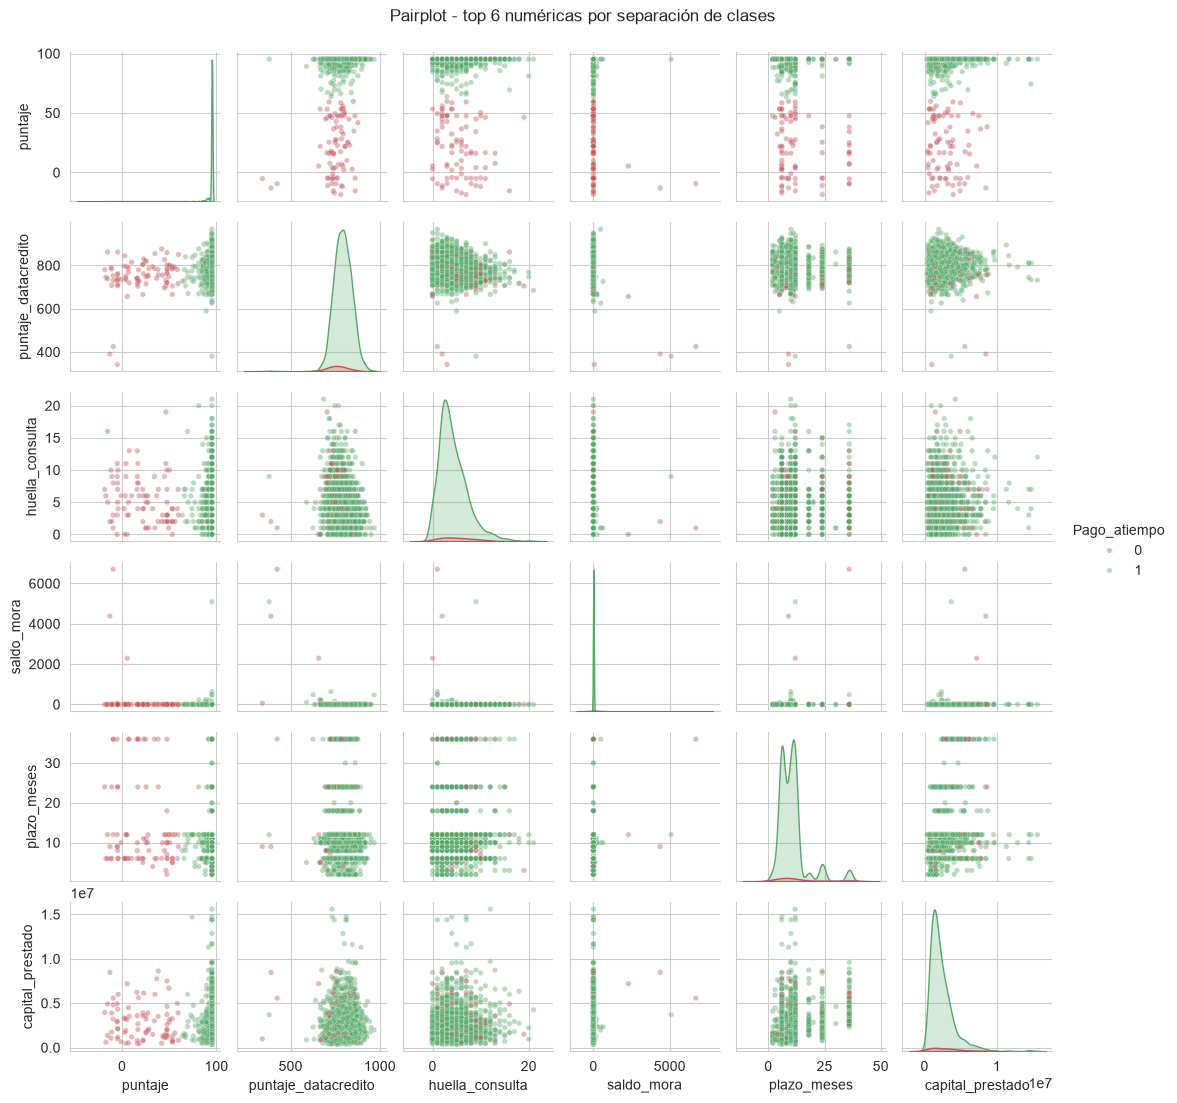

In [40]:
TOP_6_NUMERICAS = ["puntaje", "puntaje_datacredito", "huella_consulta",
                    "saldo_mora", "plazo_meses", "capital_prestado"]

muestra_pairplot = df[TOP_6_NUMERICAS + ["Pago_atiempo"]].dropna().sample(n=2000, random_state=42)

sns.pairplot(muestra_pairplot, hue="Pago_atiempo", palette={0: "#C44E52", 1: "#55A868"},
             plot_kws={"alpha": 0.4, "s": 15}, diag_kind="kde", height=1.8)
plt.suptitle("Pairplot - top 6 numéricas por separación de clases", y=1.02)
plt.show()

**Interpretación.** `puntaje` es la única variable donde las dos clases se separan a simple vista en todos los paneles donde aparece: los puntos verdes (`Pago_atiempo=1`) se concentran pegados al valor de relleno, los rojos (`Pago_atiempo=0`) se dispersan hacia valores bajos y negativos. En el resto de los cruces (`puntaje_datacredito`, `huella_consulta`, `saldo_mora`, `plazo_meses`, `capital_prestado`) las nubes de puntos de ambas clases están prácticamente superpuestas, sin una frontera visual clara — consistente con sus valores bajos en el ranking.

## Scatterplots con una tercera variable categórica

Dos cruces con lectura de negocio. En el primero se recorta `salario_cliente` a valores por debajo de 50 millones **solo para graficar** (no se toca `df`): con los outliers de miles de millones vistos en el univariable, el gráfico completo aplastaría todos los puntos reales contra el eje.

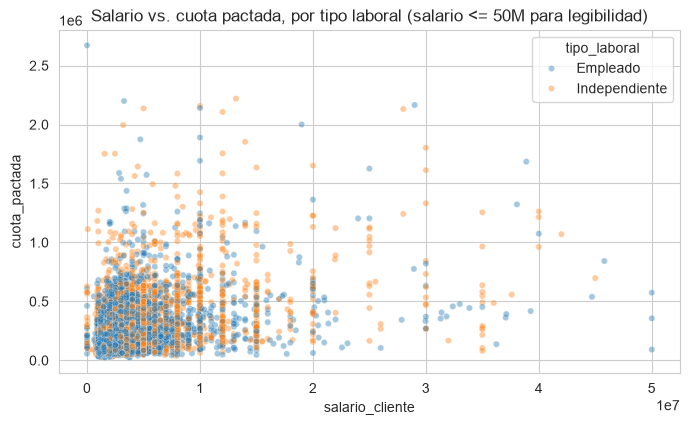

In [41]:
datos_salario = df[df["salario_cliente"] <= 50_000_000]
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=datos_salario, x="salario_cliente", y="cuota_pactada",
                 hue="tipo_laboral", alpha=0.4, s=20)
plt.title("Salario vs. cuota pactada, por tipo laboral (salario <= 50M para legibilidad)")
plt.tight_layout()
plt.show()

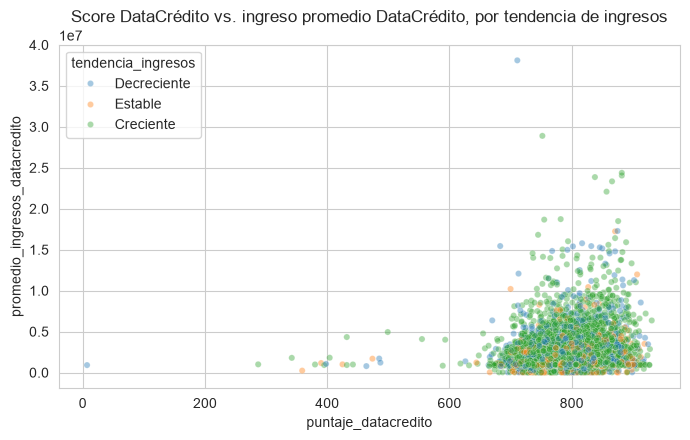

In [42]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x="puntaje_datacredito", y="promedio_ingresos_datacredito",
                 hue="tendencia_ingresos", alpha=0.4, s=20)
plt.title("Score DataCrédito vs. ingreso promedio DataCrédito, por tendencia de ingresos")
plt.tight_layout()
plt.show()

**Interpretación.** Salario vs. cuota pactada muestra una nube compacta y creciente para ambos tipos laborales, sin una separación clara entre `Empleado` e `Independiente` — la cuota pactada parece depender más del crédito (capital, plazo) que del tipo laboral del cliente. En score DataCrédito vs. ingreso promedio, tampoco aparece un patrón evidente por `tendencia_ingresos`: las tres categorías se mezclan en toda la nube de puntos, lo que sugiere que el score de buró no está fuertemente ligado al nivel de ingreso reportado por DataCrédito en este dataset.

## Tabla cruzada de tres variables

Tasa de pago a tiempo y volumen de créditos, cruzando `tipo_laboral` y `tendencia_ingresos` — tiene sentido de negocio: la situación laboral y la tendencia de ingresos son dos señales de estabilidad económica que un analista de riesgo miraría juntas, no por separado.

In [43]:
pivot_tres_variables = df.pivot_table(
    index="tipo_laboral", columns="tendencia_ingresos", values="Pago_atiempo",
    aggfunc=["mean", "count"], observed=True,
)
pivot_tres_variables

mean                           count          \
tendencia_ingresos Decreciente   Estable Creciente Decreciente Estable   
tipo_laboral                                                             
Empleado              0.941302  0.955108  0.964351         937     646   
Independiente         0.926554  0.952030  0.951757         354     542   

                              
tendencia_ingresos Creciente  
tipo_laboral                  
Empleado                3843  
Independiente           1451

**Interpretación.** La tasa de pago a tiempo se mantiene alta (>90%) en todas las combinaciones de `tipo_laboral` x `tendencia_ingresos`, sin que ninguna combinación se destaque como claramente más riesgosa — otra confirmación, ahora en un cruce de tres variables, de que ninguna de estas categóricas por sí sola (ni combinadas de a dos) separa fuerte a la variable objetivo. Las combinaciones con menos casos (celdas de `count` bajo) hay que leerlas con la misma cautela que la tasa mensual del punto 4: una tasa "distinta" ahí puede ser ruido de muestra chica, no una señal real.

# Conclusiones accionables

Esta sección conecta el EDA con la siguiente etapa del proyecto: reglas de validación reutilizables, transformaciones propuestas y atributos derivados. Todo lo que sigue está respaldado por números que ya salieron de celdas ejecutadas en este mismo notebook — no hay afirmaciones genéricas.

## Reglas de validación

Antes de correrlas como código, se corren contra una copia del CSV **recién cargada, sin el saneamiento de nulos/dominio que se hizo más arriba** en este notebook — así los conteos que se muestran reflejan lo que encontraría un pipeline real al recibir estos datos crudos, no el dataset ya limpio (donde varias de estas reglas darían 0 por construcción, porque ya se corrigieron antes).

In [44]:
RUTA_CSV_VALIDACION = RUTA_CSV  # el mismo CSV materializado por cargar_datos.ipynb

df_crudo_validacion = pd.read_csv(RUTA_CSV_VALIDACION, dtype=str, encoding="utf-8")
for columna in ["edad_cliente", "puntaje_datacredito", "saldo_principal", "saldo_total",
                "capital_prestado", "cuota_pactada", "plazo_meses"]:
    df_crudo_validacion[columna] = pd.to_numeric(df_crudo_validacion[columna], errors="coerce")
df_crudo_validacion["fecha_prestamo"] = pd.to_datetime(df_crudo_validacion["fecha_prestamo"], errors="coerce")

df_crudo_validacion.shape

(10763, 23)

In [45]:
EDAD_MIN, EDAD_MAX = 18, 100
DOMINIO_TIPO_LABORAL = {"Empleado", "Independiente"}
DOMINIO_TENDENCIA = {"Creciente", "Estable", "Decreciente"}
RATIO_MIN, RATIO_MAX = 0.714, 1.078  # límites IQR de (cuota*plazo)/capital, calculados en el multivariable

REGLAS_VALIDACION = [
    {"id": "edad_rango", "variable": "edad_cliente",
     "regla": f"{EDAD_MIN} <= edad_cliente <= {EDAD_MAX}", "tipo": "rango", "severidad": "bloqueante",
     "justificacion": "máximo observado 123 años (imposible); 150 filas (1.39%) fuera de ese rango",
     "si_falla": "marcar la fila para revisión manual, no imputar una edad automáticamente"},
    {"id": "tipo_laboral_dominio", "variable": "tipo_laboral",
     "regla": f"tipo_laboral en {sorted(DOMINIO_TIPO_LABORAL)}", "tipo": "dominio", "severidad": "advertencia",
     "justificacion": "en el EDA solo se observaron esos 2 valores, sin nulos (nunique=2)",
     "si_falla": "loguear como categoría nueva; podría ser una categoría de negocio legítima, no descartar sin revisar"},
    {"id": "tendencia_dominio", "variable": "tendencia_ingresos",
     "regla": f"tendencia_ingresos en {sorted(DOMINIO_TENDENCIA)} (o nulo)", "tipo": "dominio", "severidad": "bloqueante",
     "justificacion": "58 filas (0.54%) con valores numéricos fuera de dominio encontradas en la unificación de nulos",
     "si_falla": "convertir a NaN antes de castear a category (ya se hizo en este notebook)"},
    {"id": "puntaje_dc_rango", "variable": "puntaje_datacredito",
     "regla": "puntaje_datacredito > 0 (o nulo)", "tipo": "rango", "severidad": "bloqueante",
     "justificacion": "145 filas en 0 (tratadas como 'sin dato') + 1 fila negativa (-7, imposible)",
     "si_falla": "convertir a NaN; no usar el valor crudo como score real"},
    {"id": "saldo_consistencia", "variable": "saldo_principal / saldo_total",
     "regla": "saldo_principal <= saldo_total", "tipo": "consistencia entre columnas", "severidad": "bloqueante",
     "justificacion": "0 violaciones en 10.358 filas comparables en el EDA actual",
     "si_falla": "el crédito queda marcado para revisión, no se usa en el modelo sin corregir"},
    {"id": "ratio_cuota_capital_plazo", "variable": "cuota_pactada / capital_prestado / plazo_meses",
     "regla": f"{RATIO_MIN} <= (cuota_pactada * plazo_meses) / capital_prestado <= {RATIO_MAX}",
     "tipo": "consistencia entre columnas", "severidad": "advertencia",
     "justificacion": "559 filas (5.19%) fuera de esos límites IQR calculados sobre la razón, en el análisis multivariable",
     "si_falla": "no bloquear; marcar para revisión de la ingeniería de atributos (la relación no es una fórmula única en este dataset)"},
    {"id": "fecha_no_futura", "variable": "fecha_prestamo",
     "regla": "fecha_prestamo <= fecha de ejecución del pipeline", "tipo": "rango", "severidad": "bloqueante",
     "justificacion": "0 violaciones en el EDA actual (máximo observado 2026-04-26), pero debe sostenerse siempre",
     "si_falla": "rechazar la fila: es un error de captura o de sistema"},
    {"id": "fecha_formato", "variable": "fecha_prestamo",
     "regla": "fecha_prestamo debe ser parseable como datetime", "tipo": "formato", "severidad": "bloqueante",
     "justificacion": "0 fechas no convertibles al castear con pd.to_datetime en este notebook",
     "si_falla": "rechazar la fila: dato corrupto"},
    {"id": "fila_unica", "variable": "fila completa",
     "regla": "no debe haber filas 100% duplicadas", "tipo": "unicidad", "severidad": "advertencia",
     "justificacion": "0 filas duplicadas exactas encontradas en la descripción general (el dataset no tiene columna ID propia)",
     "si_falla": "investigar si es una recarga del mismo crédito antes de eliminar"},
]

tabla_reglas = pd.DataFrame(REGLAS_VALIDACION)[
    ["variable", "regla", "tipo", "severidad", "si_falla", "justificacion"]
]
tabla_reglas

,variable,regla,tipo,severidad,si_falla,justificacion
0,edad_cliente,18 <= edad_cliente <= 100,rango,bloqueante,"marcar la fila para revisión manual, no imputa...",máximo observado 123 años (imposible); 150 fil...
1,tipo_laboral,"tipo_laboral en ['Empleado', 'Independiente']",dominio,advertencia,loguear como categoría nueva; podría ser una c...,"en el EDA solo se observaron esos 2 valores, s..."
2,tendencia_ingresos,"tendencia_ingresos en ['Creciente', 'Decrecien...",dominio,bloqueante,convertir a NaN antes de castear a category (y...,58 filas (0.54%) con valores numéricos fuera d...
3,puntaje_datacredito,puntaje_datacredito > 0 (o nulo),rango,bloqueante,convertir a NaN; no usar el valor crudo como s...,145 filas en 0 (tratadas como 'sin dato') + 1 ...
4,saldo_principal / saldo_total,saldo_principal <= saldo_total,consistencia entre columnas,bloqueante,"el crédito queda marcado para revisión, no se ...",0 violaciones en 10.358 filas comparables en e...
5,cuota_pactada / capital_prestado / plazo_meses,0.714 <= (cuota_pactada * plazo_meses) / capit...,consistencia entre columnas,advertencia,no bloquear; marcar para revisión de la ingeni...,559 filas (5.19%) fuera de esos límites IQR ca...
6,fecha_prestamo,fecha_prestamo <= fecha de ejecución del pipeline,rango,bloqueante,rechazar la fila: es un error de captura o de ...,0 violaciones en el EDA actual (máximo observa...
7,fecha_prestamo,fecha_prestamo debe ser parseable como datetime,formato,bloqueante,rechazar la fila: dato corrupto,0 fechas no convertibles al castear con pd.to_...
8,fila completa,no debe haber filas 100% duplicadas,unicidad,advertencia,investigar si es una recarga del mismo crédito...,0 filas duplicadas exactas encontradas en la d...


## Las mismas reglas, como código reutilizable

Un modelo de Pydantic para las reglas que se pueden validar **fila por fila** (rango, dominio, consistencia entre dos columnas de la misma fila, formato), pensado para poder reusarse en un pipeline de ingesta real. Las dos reglas que necesitan mirar **todo el dataset a la vez** (la razón cuota/capital/plazo usa un límite calculado sobre la distribución completa, y la unicidad compara una fila contra todas las demás) se resuelven aparte, vectorizadas con pandas.

In [46]:
from typing import Optional
import datetime as dt

from pydantic import BaseModel, ValidationError, field_validator, model_validator


class CreditoValidado(BaseModel):
    edad_cliente: float
    tipo_laboral: str
    tendencia_ingresos: Optional[str] = None
    puntaje_datacredito: Optional[float] = None
    saldo_principal: Optional[float] = None
    saldo_total: Optional[float] = None
    fecha_prestamo: dt.datetime

    @field_validator("edad_cliente")
    @classmethod
    def _validar_edad(cls, v):
        if not (EDAD_MIN <= v <= EDAD_MAX):
            raise ValueError(f"edad_rango|{v} fuera de [{EDAD_MIN}, {EDAD_MAX}]")
        return v

    @field_validator("tipo_laboral")
    @classmethod
    def _validar_tipo_laboral(cls, v):
        if v not in DOMINIO_TIPO_LABORAL:
            raise ValueError(f"tipo_laboral_dominio|'{v}' fuera de dominio")
        return v

    @field_validator("tendencia_ingresos")
    @classmethod
    def _validar_tendencia(cls, v):
        if v is not None and v not in DOMINIO_TENDENCIA:
            raise ValueError(f"tendencia_dominio|'{v}' fuera de dominio")
        return v

    @field_validator("puntaje_datacredito")
    @classmethod
    def _validar_puntaje_dc(cls, v):
        if v is not None and v <= 0:
            raise ValueError(f"puntaje_dc_rango|{v} <= 0")
        return v

    @field_validator("fecha_prestamo")
    @classmethod
    def _validar_fecha_no_futura(cls, v):
        if v > dt.datetime.now():
            raise ValueError(f"fecha_no_futura|{v} es futura")
        return v

    @model_validator(mode="after")
    def _validar_saldo_consistente(self):
        if self.saldo_principal is not None and self.saldo_total is not None:
            if self.saldo_principal > self.saldo_total:
                raise ValueError("saldo_consistencia|saldo_principal > saldo_total")
        return self


def validar_fila(fila):
    """Devuelve el conjunto de ids de regla que viola una fila (vacío si pasa todo)."""
    try:
        CreditoValidado(
            edad_cliente=fila["edad_cliente"] if pd.notna(fila["edad_cliente"]) else 0,
            tipo_laboral=fila["tipo_laboral"],
            tendencia_ingresos=fila["tendencia_ingresos"] if pd.notna(fila["tendencia_ingresos"]) else None,
            puntaje_datacredito=fila["puntaje_datacredito"] if pd.notna(fila["puntaje_datacredito"]) else None,
            saldo_principal=fila["saldo_principal"] if pd.notna(fila["saldo_principal"]) else None,
            saldo_total=fila["saldo_total"] if pd.notna(fila["saldo_total"]) else None,
            fecha_prestamo=fila["fecha_prestamo"],
        )
        return set()
    except ValidationError as error:
        return {e["msg"].split("Value error, ")[-1].split("|")[0] for e in error.errors()}


def auditar_dataframe(df_a_validar):
    """Corre las reglas fila a fila + las reglas de dataset completo, devuelve conteos por regla."""
    violaciones_por_fila = df_a_validar.apply(validar_fila, axis=1)
    conteo = {regla["id"]: 0 for regla in REGLAS_VALIDACION}
    for reglas_violadas in violaciones_por_fila:
        for regla_id in reglas_violadas:
            conteo[regla_id] += 1

    # reglas de dataset completo
    ratio = (df_a_validar["cuota_pactada"] * df_a_validar["plazo_meses"]) / df_a_validar["capital_prestado"]
    conteo["ratio_cuota_capital_plazo"] = int(((ratio < RATIO_MIN) | (ratio > RATIO_MAX)).sum())
    conteo["fila_unica"] = int(df_a_validar.duplicated().sum())

    return conteo, violaciones_por_fila


conteo_violaciones, _ = auditar_dataframe(df_crudo_validacion)
conteo_violaciones

{'edad_rango': 150,
 'tipo_laboral_dominio': 0,
 'tendencia_dominio': 58,
 'puntaje_dc_rango': 146,
 'saldo_consistencia': 0,
 'ratio_cuota_capital_plazo': 559,
 'fecha_no_futura': 0,
 'fecha_formato': 0,
 'fila_unica': 0}

In [47]:
tabla_reglas_con_conteo = tabla_reglas.copy()
tabla_reglas_con_conteo["filas_violadoras_hoy"] = [conteo_violaciones[r["id"]] for r in REGLAS_VALIDACION]
tabla_reglas_con_conteo[["variable", "regla", "severidad", "filas_violadoras_hoy"]]

,variable,regla,severidad,filas_violadoras_hoy
0,edad_cliente,18 <= edad_cliente <= 100,bloqueante,150
1,tipo_laboral,"tipo_laboral en ['Empleado', 'Independiente']",advertencia,0
2,tendencia_ingresos,"tendencia_ingresos en ['Creciente', 'Decrecien...",bloqueante,58
3,puntaje_datacredito,puntaje_datacredito > 0 (o nulo),bloqueante,146
4,saldo_principal / saldo_total,saldo_principal <= saldo_total,bloqueante,0
5,cuota_pactada / capital_prestado / plazo_meses,0.714 <= (cuota_pactada * plazo_meses) / capit...,advertencia,559
6,fecha_prestamo,fecha_prestamo <= fecha de ejecución del pipeline,bloqueante,0
7,fecha_prestamo,fecha_prestamo debe ser parseable como datetime,bloqueante,0
8,fila completa,no debe haber filas 100% duplicadas,advertencia,0


**Interpretación.** Los conteos que arroja `auditar_dataframe` sobre los datos crudos coinciden con los números citados en la tabla de reglas — no es casualidad: son la misma fuente (este mismo EDA). Las reglas bloqueantes con violaciones reales (`edad_rango`, `puntaje_dc_rango`, `tendencia_dominio`) son justamente las que ya se corrigieron en las secciones de saneamiento de tipos más arriba; quedan documentadas acá como **guardas de entrada reutilizables** para la próxima vez que llegue una carga nueva de datos, no como un descubrimiento nuevo.

## Transformaciones propuestas

Una transformación por problema detectado, cada una con el número del EDA que la motiva.

In [48]:
TRANSFORMACIONES = [
    {"variable": "capital_prestado, cuota_pactada, promedio_ingresos_datacredito, salario_cliente, total_otros_prestamos",
     "problema_detectado": "fuertemente asimétricas a la derecha (skewness entre 3.7 y 43.8, ver tabla de univariable)",
     "transformacion_sugerida": "logaritmo (log1p)",
     "justificacion": "comportamiento log-normal confirmado en la clasificación de distribución del análisis univariable"},
    {"variable": "salario_cliente, total_otros_prestamos",
     "problema_detectado": "outliers imposibles (máximos de 22.000 millones y 6.787 millones de COP)",
     "transformacion_sugerida": "winsorización (cap en un percentil alto, ej. p99.5) antes de escalar",
     "justificacion": "37 y 22 filas por encima de 500 millones respectivamente, sección de outliers del univariable"},
    {"variable": "edad_cliente",
     "problema_detectado": "valores imposibles (máximo 123 años)",
     "transformacion_sugerida": "marcar como NaN los valores fuera de [18, 100] (regla edad_rango) e imputar por mediana",
     "justificacion": "150 filas (1.39%) fuera de rango, tabla de reglas de validación"},
    {"variable": "puntaje",
     "problema_detectado": "valor de relleno domina el 87.4% de las filas y hay valores negativos imposibles",
     "transformacion_sugerida": "separar en dos señales: una dummy binaria 'puntaje_es_relleno' + tratar los negativos como NaN",
     "justificacion": "sección de anomalías del saneamiento de tipos (87.40% en 95.227787, 1.25% negativos)"},
    {"variable": "puntaje_datacredito",
     "problema_detectado": "nulos moderados tras el saneamiento (1.40%) en una distribución razonablemente simétrica",
     "transformacion_sugerida": "imputación por mediana",
     "justificacion": "151 nulos tras la unificación, tabla de comparación de nulos"},
    {"variable": "tendencia_ingresos, promedio_ingresos_datacredito",
     "problema_detectado": "~27% de nulos, concentrados aparentemente en el mismo bloque de créditos",
     "transformacion_sugerida": "categoría explícita 'Sin dato' (o imputación por modelo) en vez de imputación simple",
     "justificacion": "27.78% y 27.22% de nulos respectivamente, tabla de comparación de nulos"},
    {"variable": "tipo_credito",
     "problema_detectado": "categorías muy raras (código '7' en 0.02%, '68' en 0.01%)",
     "transformacion_sugerida": "agrupar categorías raras en 'Otros' antes de one-hot encoding",
     "justificacion": "tabla de frecuencias de categóricas del análisis univariable"},
    {"variable": "tipo_laboral",
     "problema_detectado": "ninguno (dicotómica limpia, sin nulos)",
     "transformacion_sugerida": "encoding binario 0/1",
     "justificacion": "2 categorías, 0% de nulos, tabla de caracterización de variables"},
    {"variable": "tendencia_ingresos",
     "problema_detectado": "es ordinal, no nominal",
     "transformacion_sugerida": "encoding ordinal (Decreciente=0, Estable=1, Creciente=2), no one-hot",
     "justificacion": "definida como categórica ordinal en la caracterización de variables, con orden de negocio claro"},
    {"variable": "saldo_mora, saldo_mora_codeudor",
     "problema_detectado": "casi constantes en 0 (99.48% / 99.97%) y duplicadas entre sí (99.69% de coincidencia)",
     "transformacion_sugerida": "conservar una sola, transformada a binaria 'tiene_mora' en vez de la magnitud",
     "justificacion": "tabla de candidatas a eliminar del saneamiento de tipos"},
    {"variable": "todas las numéricas (para modelos lineales o basados en distancia, no para árboles)",
     "problema_detectado": "outliers extremos en casi todas las columnas",
     "transformacion_sugerida": "escalado robusto (RobustScaler, basado en mediana/IQR en vez de media/desvío)",
     "justificacion": "tabla comparativa de outliers IQR vs. z-score del análisis univariable"},
]

pd.DataFrame(TRANSFORMACIONES)

,variable,problema_detectado,transformacion_sugerida,justificacion
0,"capital_prestado, cuota_pactada, promedio_ingr...",fuertemente asimétricas a la derecha (skewness...,logaritmo (log1p),comportamiento log-normal confirmado en la cla...
1,"salario_cliente, total_otros_prestamos",outliers imposibles (máximos de 22.000 millone...,"winsorización (cap en un percentil alto, ej. p...",37 y 22 filas por encima de 500 millones respe...
2,edad_cliente,valores imposibles (máximo 123 años),"marcar como NaN los valores fuera de [18, 100]...","150 filas (1.39%) fuera de rango, tabla de reg..."
3,puntaje,valor de relleno domina el 87.4% de las filas ...,separar en dos señales: una dummy binaria 'pun...,sección de anomalías del saneamiento de tipos ...
4,puntaje_datacredito,nulos moderados tras el saneamiento (1.40%) en...,imputación por mediana,"151 nulos tras la unificación, tabla de compar..."
5,"tendencia_ingresos, promedio_ingresos_datacredito","~27% de nulos, concentrados aparentemente en e...",categoría explícita 'Sin dato' (o imputación p...,"27.78% y 27.22% de nulos respectivamente, tabl..."
6,tipo_credito,"categorías muy raras (código '7' en 0.02%, '68...",agrupar categorías raras en 'Otros' antes de o...,tabla de frecuencias de categóricas del anális...
7,tipo_laboral,"ninguno (dicotómica limpia, sin nulos)",encoding binario 0/1,"2 categorías, 0% de nulos, tabla de caracteriz..."
8,tendencia_ingresos,"es ordinal, no nominal","encoding ordinal (Decreciente=0, Estable=1, Cr...",definida como categórica ordinal en la caracte...
9,"saldo_mora, saldo_mora_codeudor",casi constantes en 0 (99.48% / 99.97%) y dupli...,"conservar una sola, transformada a binaria 'ti...",tabla de candidatas a eliminar del saneamiento...


**Interpretación.** La mayoría de las transformaciones apunta a dos problemas recurrentes ya vistos en el EDA: **asimetría fuerte** (casi todas las numéricas de monto) y **outliers que van de "plausibles" a "imposibles"** (edad, salario, puntaje, puntaje_datacredito). Ninguna transformación toca `saldo_mora`/`saldo_mora_codeudor` para eliminarlas todavía — siguen pendientes de tu confirmación, como se dejó explícito en la sección de candidatas a eliminar.

## Atributos derivados

Al menos 8 variables calculadas, con su fórmula y su lógica de negocio. `fecha_referencia` usa el máximo `fecha_prestamo` del propio dataset (no la fecha real de hoy), para que la antigüedad calculada sea reproducible sin importar cuándo se corra el notebook.

In [49]:
fecha_referencia = df["fecha_prestamo"].max()

df["ratio_cuota_ingreso"] = df["cuota_pactada"] / df["salario_cliente"].replace(0, np.nan)
df["ratio_endeudamiento"] = (df["total_otros_prestamos"] + df["saldo_total"]) / df["salario_cliente"].replace(0, np.nan)
df["ratio_cuota_capital"] = df["cuota_pactada"] / df["capital_prestado"]
df["ratio_saldo_mora_total"] = df["saldo_mora"] / df["saldo_total"].replace(0, np.nan)
df["antiguedad_credito_dias"] = (fecha_referencia - df["fecha_prestamo"]).dt.days
df["total_creditos_todos_sectores"] = (
    df["creditos_sectorFinanciero"] + df["creditos_sectorCooperativo"] + df["creditos_sectorReal"]
)
df["pct_creditos_sector_financiero"] = (
    df["creditos_sectorFinanciero"] / df["total_creditos_todos_sectores"].replace(0, np.nan)
)
df["ratio_capital_ingreso"] = df["capital_prestado"] / df["salario_cliente"].replace(0, np.nan)
df["saldo_no_principal"] = df["saldo_total"] - df["saldo_principal"]

ATRIBUTOS_DERIVADOS = [
    {"atributo": "ratio_cuota_ingreso", "formula": "cuota_pactada / salario_cliente",
     "logica_de_negocio": "capacidad de pago: qué fracción del ingreso mensual se va en la cuota de este crédito"},
    {"atributo": "ratio_endeudamiento", "formula": "(total_otros_prestamos + saldo_total) / salario_cliente",
     "logica_de_negocio": "endeudamiento total (otras deudas + saldo vigente) relativo al ingreso"},
    {"atributo": "ratio_cuota_capital", "formula": "cuota_pactada / capital_prestado",
     "logica_de_negocio": "qué fracción del capital se paga por cuota; aproxima el ritmo real de pago"},
    {"atributo": "ratio_saldo_mora_total", "formula": "saldo_mora / saldo_total",
     "logica_de_negocio": "proporción del saldo total que está en mora; señal directa de deterioro"},
    {"atributo": "antiguedad_credito_dias", "formula": "fecha_referencia - fecha_prestamo",
     "logica_de_negocio": "antigüedad del crédito en días, para detectar efectos de vintage/cosecha"},
    {"atributo": "total_creditos_todos_sectores", "formula": "suma de creditos_sector{Financiero,Cooperativo,Real}",
     "logica_de_negocio": "exposición total del cliente en el sistema financiero, agregando los tres sectores"},
    {"atributo": "pct_creditos_sector_financiero", "formula": "creditos_sectorFinanciero / total_creditos_todos_sectores",
     "logica_de_negocio": "concentración de la exposición del cliente en el sector financiero vs. cooperativo/real"},
    {"atributo": "ratio_capital_ingreso", "formula": "capital_prestado / salario_cliente",
     "logica_de_negocio": "tamaño del crédito relativo al ingreso: a cuántos meses de sueldo equivale"},
    {"atributo": "saldo_no_principal", "formula": "saldo_total - saldo_principal",
     "logica_de_negocio": "parte del saldo que no es capital (intereses/mora acumulada); deterioro adicional a saldo_mora"},
]
pd.DataFrame(ATRIBUTOS_DERIVADOS)

,atributo,formula,logica_de_negocio
0,ratio_cuota_ingreso,cuota_pactada / salario_cliente,capacidad de pago: qué fracción del ingreso me...
1,ratio_endeudamiento,(total_otros_prestamos + saldo_total) / salari...,endeudamiento total (otras deudas + saldo vige...
2,ratio_cuota_capital,cuota_pactada / capital_prestado,qué fracción del capital se paga por cuota; ap...
3,ratio_saldo_mora_total,saldo_mora / saldo_total,proporción del saldo total que está en mora; s...
4,antiguedad_credito_dias,fecha_referencia - fecha_prestamo,"antigüedad del crédito en días, para detectar ..."
5,total_creditos_todos_sectores,"suma de creditos_sector{Financiero,Cooperativo...",exposición total del cliente en el sistema fin...
6,pct_creditos_sector_financiero,creditos_sectorFinanciero / total_creditos_tod...,concentración de la exposición del cliente en ...
7,ratio_capital_ingreso,capital_prestado / salario_cliente,tamaño del crédito relativo al ingreso: a cuán...
8,saldo_no_principal,saldo_total - saldo_principal,parte del saldo que no es capital (intereses/m...


In [50]:
df[[a["atributo"] for a in ATRIBUTOS_DERIVADOS]].describe()

,ratio_cuota_ingreso,ratio_endeudamiento,ratio_cuota_capital,ratio_saldo_mora_total,antiguedad_credito_dias,total_creditos_todos_sectores,pct_creditos_sector_financiero,ratio_capital_ingreso,saldo_no_principal
count,10739.000000,10584.000000,10763.000000,9818.000000,10763.000000,10763.000000,10059.000000,10739.000000,1.035800e+04
mean,0.094674,0.705484,0.109496,0.000460,374.589891,4.352504,0.633305,0.921763,6.695547e+03
std,1.243445,24.820949,0.054899,0.014283,103.761974,3.489233,0.338674,8.341662,7.318832e+04
min,0.000008,0.000000,0.016934,0.000000,0.000000,0.000000,0.000000,0.000106,0.000000e+00
25%,0.038713,0.222260,0.078467,0.000000,314.000000,2.000000,0.400000,0.370204,0.000000e+00
50%,0.060864,0.353711,0.092470,0.000000,395.000000,4.000000,0.666667,0.633061,0.000000e+00
75%,0.095371,0.487939,0.148528,0.000000,461.000000,6.000000,1.000000,1.020678,0.000000e+00
max,125.802000,2498.583000,0.416667,1.000000,516.000000,60.000000,1.000000,840.000000,4.617429e+06


**Interpretación.** Todos los ratios que dividen por `salario_cliente` (`ratio_cuota_ingreso`, `ratio_endeudamiento`, `ratio_capital_ingreso`) van a heredar el mismo problema de outliers extremos que ya tiene `salario_cliente` (los 24 casos en 0 quedan como `NaN` por el `.replace(0, np.nan)`, y los valores de miles de millones van a generar ratios absurdamente chicos) — estos atributos necesitan la misma winsorización propuesta para `salario_cliente` antes de usarse en un modelo. `antiguedad_credito_dias` da valores no negativos por construcción, ya que `fecha_referencia` es el máximo de la propia columna.

## Resumen ejecutivo del EDA

**5 hallazgos principales:**
1. Fuerte desbalance de clases en `Pago_atiempo` (95.25% / 4.75%): condiciona la métrica (nada de accuracy) y probablemente exige balanceo de clases al modelar.
2. `puntaje` correlaciona ~0.92 con el objetivo y tiene un valor de relleno en 87.4% de las filas: **sospecha fuerte de data leakage**, a confirmar con negocio antes de usarla como feature.
3. Hay valores imposibles en varias columnas clave: edad de 123 años, salarios de miles de millones de COP, `puntaje_datacredito` negativo — ya cubiertos por las reglas de validación de esta sección.
4. `saldo_mora` y `saldo_mora_codeudor` son casi constantes en 0 y están duplicadas entre sí (99.69% de coincidencia): candidatas a eliminar o combinar, pendientes de tu confirmación.
5. Casi todas las numéricas de monto son fuertemente asimétricas a la derecha (log-normales); `saldo_total` y `saldo_principal` están altamente correlacionadas por Spearman (0.946) pero no tanto por Pearson (0.735), por los mismos outliers.

**Principales riesgos para el modelado:**
- Si `puntaje` resulta ser leakage real, el resto de las variables individuales tiene muy poco poder predictivo aislado (todas |corr|<0.12 contra el objetivo) — el modelo va a depender de combinaciones/interacciones, no de una variable dominante "sana".
- El desbalance de clases puede inflar el accuracy y esconder un mal desempeño en la clase minoritaria (el no-pago, que es la que le importa al negocio).
- Sin winsorizar/tratar los outliers imposibles, cualquier modelo sensible a escala (regresión, distancia, redes) va a quedar dominado por un puñado de filas erróneas.